# Inter-GNN scope (`inter_gnn_b1000_pcgrad`) — Gradient Dynamics 분석 노트북

이 노트북은 `gradient_analysis_results/inter_gnn_b1000_pcgrad` 산출물을 읽어 분석합니다.
**`inter_gnn_b2000` 대비 두 가지 변화**:
1. **PCGrad probe variants 추가** — `raw` + `pcgrad_strict` + `pcgrad_normpreserved` (b2000 은 `raw`/`normalized`).
2. **4개 checkpoint** — `1ep`, `3ep`, `9ep`, `18ep` (b2000 은 1ep/18ep 두 끝점만).

## 실험 정의 — `tools/anal*.sh` / `configs/gradient_analysis_b2000.yaml`

| 항목 | 값 |
|---|---|
| Adapter | `hipad` |
| Model config | `projects/configs/experiments/E2_E1_stage2_18ep_grad_analysis.py` |
| Checkpoint root | `/home/yongjae/e2e/HiP-AD/work_dirs/E2_rev` |
| Checkpoints | `1ep=iter_1758`, `3ep=iter_5274`, `9ep=iter_15822`, `18ep=iter_31644` |
| Modules | `M2` (gradient conflict), `M3` (1-step probe), `M_PI` (planning importance) |
| Probe layers | `dec0_inter_gnn_0`, `dec1_inter_gnn_0`, `dec2_inter_gnn_0` (3 inter-task GNN sub-layers) |
| Probe | `alpha=0.001`, `steps=[1]`, `variants=[raw, pcgrad_strict, pcgrad_normpreserved]` |
| Determinism | `freeze_matching=true`, `reset_temporal_state=true`, `forward_seed=42` |
| Tasks | `det`, `map`, `motion`, `plan` |

> **1ep 주의** — 초기 1ep run 은 M3 phase batch 108 에서 `RuntimeError: _Map_base::at`
> 으로 중단되었다. `probe.run_m3` / `run_alpha_sweep` 에 batch-level try/except 가드를 추가
> 한 뒤 재실행했고, 실패한 batch 들은 `ckpt_1ep/probe/skipped_batches.csv` 에 기록된다.
> 평균과 CI 는 valid batch 만으로 계산되므로 분석에는 영향이 적지만, 1ep 의 sample size
> 가 다른 ckpt 와 살짝 다를 수 있어 **§1.1 의 토글 셀** 로 분석에서 통째로 빼볼 수 있다.


## 0. 개념과 지표 정의

### 0.1 Task
- `det` (3D object detection), `map` (HD-map vectorization), `motion` (multi-agent motion forecasting), `plan` (ego planning).
- 학습 loss = `λ_det·L_det + λ_map·L_map + λ_motion·L_motion + λ_plan·L_plan + (depth aux)`

### 0.2 Gradient cosine (`M2`)
- 공유 파라미터 `θ_s` 에 대해 각 task gradient `g_t = ∂L_t / ∂θ_s` 계산.
- 두 task `(a, b)` 의 cosine `c = g_a · g_b / (‖g_a‖·‖g_b‖)`.
  - `c > 0` → 두 task 가 같은 방향으로 θ 를 밀어 **협력**.
  - `c < 0` → 반대 방향으로 밀어 **충돌**.
  - `c ≈ 0` → 직교 / 약신호.
- 본 노트북은 `inter_gnn` scope 안의 6 layer 에 대해 batch 단위로 cosine 을 모은 후 다음을 집계:
  - **`conflict_ratio`** = 음수 cosine 비율. 0.5 보다 의미 있게 크면 direction conflict 후보.
  - **`mean_cos` / `median_cos`** — 효과 크기. 부호 + 절댓값을 같이 봐야 함.
  - **CI** (`conflict_ratio_ci_lo/hi`, `mean_cos_ci_lo/hi`) — bootstrap 95%.
- 산출물 위치:
  - `conflict/conflict_<a>_<b>_summary.csv` — `neck`, `fc_before`, `fc_after` 같이 학습이 실제로 공유하는 그룹.
  - `layer_conflict/conflict_<a>_<b>_summary.csv` — `dec{N}_inter_gnn_0` 단위로 더 잘게 나눈 그룹.

### 0.3 1-step probe (`M3`)
- source task `s` 의 gradient 로 `θ_s ← θ_s − α · g_s` 한 번 step 한 뒤, target task `t` 의 loss 변화 `Δ_st = L_t(θ_s) − L_t(θ_0)` 측정.
- variants:
  - `raw`: `α = 0.001` 그대로 (gradient norm 효과 포함).
  - `normalized`: gradient 를 단위 norm 으로 만든 뒤 step → **방향 효과만** 분리.
- 대각선 (`s == t`): self-step 으로 self-loss 가 줄어야 정상 (`Δ_ss < 0`) — sanity check.
- 비대각:
  - `Δ_st < 0` → s 의 step 이 t 도 개선 → **transfer** (협력).
  - `Δ_st > 0` → s 의 step 이 t 를 악화 → **interference**.
- 본 scope 에서는 `target_layers = dec0..dec5_inter_gnn_0` 각각에 대해 4×4 source→target matrix 가 생성됨.
- 산출물:
  - `probe/probe_per_batch.csv` — `(batch_idx, source, target, layer, variant, delta, rel_delta, …)`
  - `probe/probe_matrix_dec{N}_inter_gnn_0_1step_{raw,normalized}{,_ci_lo,_ci_hi}.csv` — 평균/CI matrix.

### 0.4 Planning importance (`M_PI`)
- direction.md item 3 — "**planning 에 도움 주는 task 를 어떻게 판단할 것인가**" 정량화.
- 두 가지 지표:
  - **alignment** (cheap proxy): `align_score = mean_t cos(g_plan, g_aux)` — 같은 방향이면 양수.
  - **transfer** (causal): `transfer_gain = −E[Δ_{aux→plan}]` (probe 결과). 양수면 aux step 이 plan loss 를 줄임.
- **agreement**: 둘이 같은 task 를 1위로 가리키면 "cosine proxy 가 causal 과 일치" → online weighting 의 근거.
- **scene-dependence**: scene(batch) 별로 winner 가 누구냐 → normalized entropy 가 1.0 이면 task 가 scene 마다 바뀜 → per-scene weighting 의 근거.
- 추가: `planning_layer_sensitivity.csv` — layer 별 `mean ‖g_plan‖` (planning gradient 가 어디서 강한가).

### 0.5 결정성 (왜 이 세팅인가)
- 같은 batch 에 대해 baseline forward / grad forward / stepped forward 를 비교해야 하므로, 세 forward 사이에 **모든 비결정적 요인을 제거**해야 함:
  - `freeze_matching=true`: Hungarian (det/map) + mode-argmin (motion/plan) 결과를 baseline 에 고정 → matching 재섞임으로 인한 Δloss 오염 방지.
  - `reset_temporal_state=true`: InstanceBank temporal cache, sampler `dn_metas`, `run_step` 을 매 forward 전 복원.
  - `forward_seed=42`: DN noise + GridMask augmentation 의 numpy/random seed 고정.
  - 이 셋이 모두 켜져 있어야 drift `~0` 으로 떨어짐 (이력: 2026-04-30, `diag_forward_determinism.py`).

## 1. 데이터 로딩

In [1]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import MultipleLocator
from IPython.display import Image, Markdown, display

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 110

REPO_ROOT = Path('/home/yongjae/e2e/HiP-AD-pcgrad')
RESULTS_ROOT = REPO_ROOT / 'gradient_analysis_results' / 'inter_gnn_b1000_pcgrad'

# === anal*.sh 그대로 명시 — b1000_pcgrad run 은 4 ckpt × inter_gnn dec0..2 ===
ITERS_PER_EPOCH = 1758  # E2_E1_stage2_18ep_new.py: num_iters_per_epoch
CKPT_ITER_MAP = {
    '1ep':   1 * 1758,   #  1758
    '3ep':   3 * 1758,   #  5274
    '9ep':   9 * 1758,   # 15822
    '18ep': 18 * 1758,   # 31644
}
# anal*.sh `--probe-layers` 와 정확히 동일한 순서.
TARGET_LAYERS = [
    'dec0_inter_gnn_0', 'dec1_inter_gnn_0', 'dec2_inter_gnn_0',
]
TASK_ORDER = ['det', 'map', 'motion', 'plan']

# M3 variants in this run (b2000 used [raw, normalized]; b1000_pcgrad uses [raw, pcgrad_*]).
M3_VARIANTS = ['raw', 'pcgrad_strict', 'pcgrad_normpreserved']
# Default variant for the §4 'one-step probe' matrix views. b2000 used 'normalized';
# this run has no 'normalized' so we default to 'raw'.
DEFAULT_PROBE_VARIANT = 'raw'

def _real_epoch(iter_n):
    return iter_n / ITERS_PER_EPOCH

def set_epoch_xaxis(ax, step=1):
    """Force x-axis (real epoch) to integer-step ticks (default 1)."""
    ax.xaxis.set_major_locator(MultipleLocator(step))


### 1.1 1ep 포함 여부 토글

1ep run 은 batch-skip 가드로 일부 batch (`skipped_batches.csv` 참고) 가 평균에서
빠진다. 분석에 1ep 를 통째로 빼고 싶으면 아래 `INCLUDE_1EP = False` 로 두고 셀들을
다시 실행하면 된다. 모든 후속 시각화는 `CKPTS` 리스트만 본다.

In [2]:
# ▶▶  1ep 분석 포함 여부  ◀◀
INCLUDE_1EP = True  # False -> 1ep 를 모든 시각화/통계에서 제외

CKPT_DIRS = sorted(
    [p for p in RESULTS_ROOT.glob('ckpt_*ep') if p.is_dir()],
    key=lambda p: CKPT_ITER_MAP.get(p.name.replace('ckpt_', ''), 10**9),
)
CKPTS = []  # list of (tag, iter, real_epoch, path)
for p in CKPT_DIRS:
    tag = p.name.replace('ckpt_', '')
    if tag not in CKPT_ITER_MAP:
        print(f'[skip] ckpt tag {tag!r} not in map — ignoring')
        continue
    if (not INCLUDE_1EP) and tag == '1ep':
        print(f'[skip] {tag} (INCLUDE_1EP=False)')
        continue
    it = CKPT_ITER_MAP[tag]
    CKPTS.append((tag, it, _real_epoch(it), p))

print(f'INCLUDE_1EP = {INCLUDE_1EP}')
print('Available checkpoints (tag -> iter -> real epoch):')
for tag, it, ep, p in CKPTS:
    sub = sorted([d.name for d in p.iterdir() if d.is_dir()])
    print(f'  {tag:6s}  iter_{it:>5d}  real_epoch={ep:5.2f}  modules={sub}')


INCLUDE_1EP = True
Available checkpoints (tag -> iter -> real epoch):
  1ep     iter_ 1758  real_epoch= 1.00  modules=['conflict', 'layer_conflict', 'planning_importance', 'probe']
  3ep     iter_ 5274  real_epoch= 3.00  modules=['conflict', 'layer_conflict', 'planning_importance', 'probe']
  9ep     iter_15822  real_epoch= 9.00  modules=['conflict', 'layer_conflict', 'planning_importance', 'probe']
  18ep    iter_31644  real_epoch=18.00  modules=['conflict', 'layer_conflict', 'planning_importance', 'probe']


In [3]:
def _stack(rel_glob):
    """Stack per-ckpt CSVs and inject (tag, iter, real_epoch) columns."""
    frames = []
    for tag, it, ep, p in CKPTS:
        for f in sorted(p.glob(rel_glob)):
            try:
                df = pd.read_csv(f)
            except Exception as e:
                print(f'[skip] {f}: {e}')
                continue
            df['checkpoint'] = tag
            df['iter'] = it
            df['epoch'] = ep
            df['__file'] = f.name
            frames.append(df)
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

conflict_shared = _stack('conflict/conflict_*_summary.csv')
conflict_layer  = _stack('layer_conflict/conflict_*_summary.csv')
probe_per_batch = _stack('probe/probe_per_batch.csv')
pi_summary      = _stack('planning_importance/importance_summary.csv')
pi_layer_sens   = _stack('planning_importance/planning_layer_sensitivity.csv')
pi_winner_dist  = _stack('planning_importance/scene_winner_distribution.csv')
pi_winner_pb    = _stack('planning_importance/scene_winner_per_batch.csv')
pi_agreement    = _stack('planning_importance/alignment_transfer_agreement.csv')

print('Loaded shapes:')
for name, df in [('conflict_shared', conflict_shared),
                 ('conflict_layer',  conflict_layer),
                 ('probe_per_batch', probe_per_batch),
                 ('pi_summary',      pi_summary),
                 ('pi_layer_sens',   pi_layer_sens),
                 ('pi_winner_dist',  pi_winner_dist),
                 ('pi_winner_pb',    pi_winner_pb),
                 ('pi_agreement',    pi_agreement)]:
    ckpts = sorted(df['checkpoint'].unique()) if len(df) else []
    print(f'  {name:20s}  rows={len(df):>7d}  ckpts={ckpts}')

Loaded shapes:
  conflict_shared       rows=     72  ckpts=['18ep', '1ep', '3ep', '9ep']
  conflict_layer        rows=     72  ckpts=['18ep', '1ep', '3ep', '9ep']
  probe_per_batch       rows= 673120  ckpts=['18ep', '1ep', '3ep', '9ep']
  pi_summary            rows=     12  ckpts=['18ep', '1ep', '3ep', '9ep']
  pi_layer_sens         rows=     12  ckpts=['18ep', '1ep', '3ep', '9ep']
  pi_winner_dist        rows=     24  ckpts=['18ep', '1ep', '3ep', '9ep']
  pi_winner_pb          rows=   8000  ckpts=['18ep', '1ep', '3ep', '9ep']
  pi_agreement          rows=      4  ckpts=['18ep', '1ep', '3ep', '9ep']


### 1.2 Skipped-batch 보고 (M3 가드)

`run_m3` / `run_alpha_sweep` 의 batch-level try/except 가 적어 둔 `skipped_batches.csv`
가 있으면 ckpt 별로 표시. 빈 dataframe 이면 모든 batch 가 정상 통과.

In [4]:
skipped_rows = []
for tag, it, ep, p in CKPTS:
    for f in sorted(p.glob('probe/skipped_batches.csv')) + \
             sorted(p.glob('probe/skipped_alpha_*.csv')):
        try:
            df = pd.read_csv(f)
        except Exception as e:
            print(f'[skip] {f}: {e}'); continue
        df['checkpoint'] = tag
        df['iter'] = it
        df['epoch'] = ep
        df['__file'] = f.name
        skipped_rows.append(df)
skipped_df = pd.concat(skipped_rows, ignore_index=True) if skipped_rows else pd.DataFrame()

if skipped_df.empty:
    print('[skipped_batches] no skipped batches recorded — all M3 batches completed cleanly.')
else:
    summary = (skipped_df.groupby(['checkpoint', '__file'])
                          .size().reset_index(name='n_skipped')
                          .sort_values(['checkpoint', '__file']))
    print('=== skipped batch counts per ckpt ===')
    display(summary)
    print('\n=== first 20 skipped rows ===')
    display(skipped_df.head(20))


[skipped_batches] no skipped batches recorded — all M3 batches completed cleanly.


## 2. Conflict 개요 — `M2`

### 2.1 무엇을 보는가
각 (ckpt, task pair, group) cell 에 대해 batch 100개의 cosine 분포를 요약한 `conflict_ratio` / `mean_cos` 를 본다. 두 경계가 핵심이다.
- `conflict_ratio = 0.5` (random baseline). 의미 있게 넘으면 direction conflict 후보.
- `mean_cos = 0` (균형). 음수면 평균적으로 충돌, 양수면 협력.

### 2.2 어떻게 읽는가
- **CI 가 0.5 를 포함**하면 noise 와 구분이 안 된다 — direction surgery 근거 약함.
- `conflict_ratio` 가 크더라도 `mean_cos` 가 `-0.01` 수준이면 평균 효과 크기는 작다 — 부호만 음수일 뿐.
- shared group (`neck/fc_*`) vs layer group (`dec{N}_inter_gnn_0`): shared 는 큰 변수에 평균을 내 신호가 흐려지기 쉽고, layer 는 더 잘게 봐서 어느 깊이에서 충돌이 모이는지 보인다.

### 2.3 액션 트리거
- `conflict_ratio_ci_lo > 0.55` 인 (task pair, group) cell ≥ 1 → 그 pair·group 을 sandbox 에서 PCGrad/CAGrad 대상으로.
- 그렇지 않으면 "direction conflict 신호 약함" → magnitude rescaling / task weighting 쪽으로 우선순위 이동.

In [5]:
def real_only(df):
    if df.empty or 'is_pseudo_shared_group' not in df.columns:
        return df
    return df[~df['is_pseudo_shared_group'].astype(bool)].copy()

real_shared = real_only(conflict_shared)
real_layer  = real_only(conflict_layer)

def overview(df, title):
    if df.empty:
        print(f'[{title}] empty'); return
    g = (df.groupby(['checkpoint', 'iter', 'epoch'], as_index=False)
           .agg(mean_conflict_ratio=('conflict_ratio', 'mean'),
                med_conflict_ratio=('conflict_ratio', 'median'),
                max_conflict_ratio=('conflict_ratio', 'max'),
                mean_cos=('mean_cos', 'mean'),
                n_cells=('conflict_ratio', 'size'))
           .sort_values('iter'))
    print(f'\n[{title}]')
    display(g.round(4))

overview(real_shared, 'shared groups (neck / fc_before / fc_after)')
overview(real_layer,  f'layer groups ({len(TARGET_LAYERS)} inter-GNN layers)')


[shared groups (neck / fc_before / fc_after)]


,checkpoint,iter,epoch,mean_conflict_ratio,med_conflict_ratio,max_conflict_ratio,mean_cos,n_cells
1,1ep,1758,1.0,0.4203,0.4715,0.565,0.0361,18
2,3ep,5274,3.0,0.3966,0.4635,0.523,0.0338,18
3,9ep,15822,9.0,0.3981,0.4420,0.511,0.0283,18
0,18ep,31644,18.0,0.4035,0.4595,0.497,0.0291,18



[layer groups (3 inter-GNN layers)]


,checkpoint,iter,epoch,mean_conflict_ratio,med_conflict_ratio,max_conflict_ratio,mean_cos,n_cells
1,1ep,1758,1.0,0.4229,0.475,0.558,0.0377,18
2,3ep,5274,3.0,0.4108,0.470,0.513,0.0347,18
3,9ep,15822,9.0,0.4092,0.474,0.526,0.0312,18
0,18ep,31644,18.0,0.4091,0.463,0.498,0.0322,18


=== shared groups ===


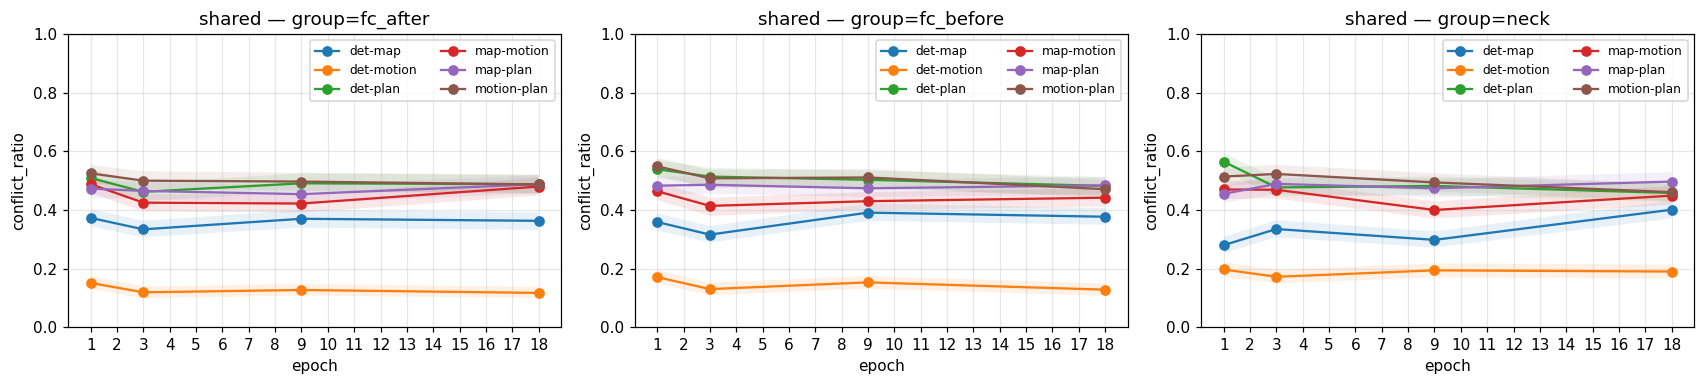

In [6]:
def plot_conflict_ratio_by_pair(df, title, x='epoch'):
    if df.empty:
        print(f'[{title}] empty'); return
    d = df.copy()
    d['pair'] = d['task_a'] + '-' + d['task_b']
    groups = sorted(d['group'].unique())
    ncols = min(3, len(groups))
    nrows = int(np.ceil(len(groups) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.2 * ncols, 3.6 * nrows), squeeze=False)
    for ax, g in zip(axes.ravel(), groups):
        sub = d[d['group'] == g].sort_values(x)
        for pair, pdf in sub.groupby('pair'):
            pdf = pdf.sort_values(x)
            ax.plot(pdf[x], pdf['conflict_ratio'], marker='o', label=pair)
            if {'conflict_ratio_ci_lo', 'conflict_ratio_ci_hi'}.issubset(pdf.columns):
                ax.fill_between(pdf[x], pdf['conflict_ratio_ci_lo'],
                                pdf['conflict_ratio_ci_hi'], alpha=0.10)
        ax.axhline(1, color='gray', ls='--', lw=0.8)
        ax.set_title(f'{title} — group={g}')
        ax.set_xlabel(x); ax.set_ylabel('conflict_ratio')
        ax.set_ylim(0, 1.0); ax.grid(alpha=0.3)
        if x == 'epoch':
            set_epoch_xaxis(ax, step=1)
        ax.legend(fontsize=8, ncol=2)
    for ax in axes.ravel()[len(groups):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

print('=== shared groups ===')
plot_conflict_ratio_by_pair(real_shared, 'shared')

=== inter-GNN layer groups ===


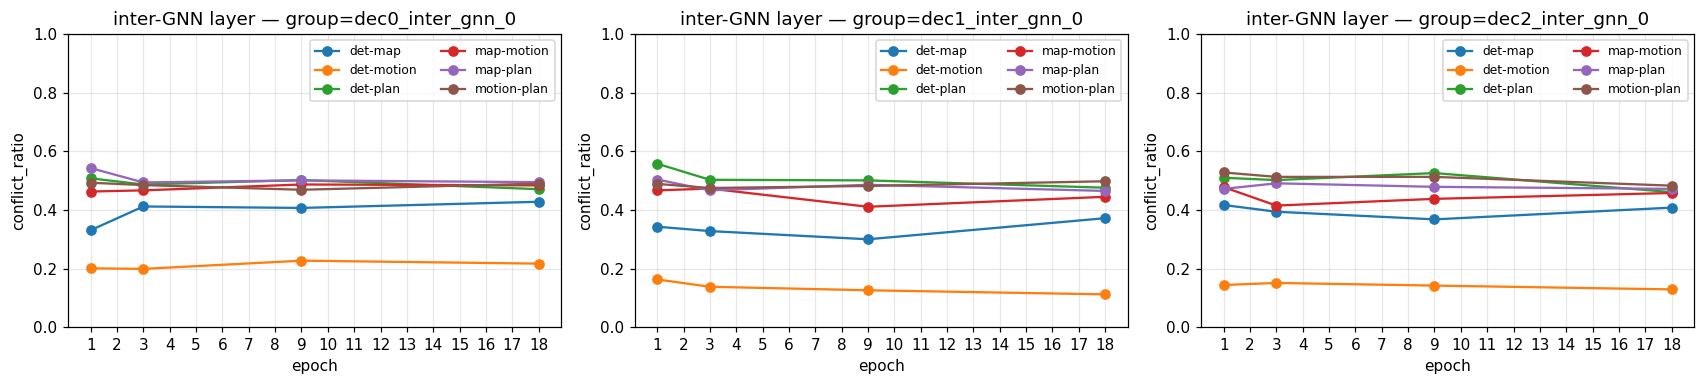

In [7]:
print('=== inter-GNN layer groups ===')
plot_conflict_ratio_by_pair(real_layer, 'inter-GNN layer')

In [8]:
# 모든 ckpt × pair × group 셀에서 가장 충돌이 큰/작은 셀 (real only)
if not real_layer.empty:
    base_cols = ['checkpoint', 'iter', 'task_a', 'task_b', 'group',
                 'conflict_ratio', 'mean_cos']
    ci_cols = [c for c in ['conflict_ratio_ci_lo', 'conflict_ratio_ci_hi']
               if c in real_layer.columns]
    cols = base_cols + ci_cols
    base = real_layer[cols].sort_values('conflict_ratio', ascending=False)
    print('Top 10 highest conflict_ratio (layer groups)')
    display(base.head(10).round(4).reset_index(drop=True))
    print('\nTop 10 lowest conflict_ratio (most cooperative)')
    display(base.tail(10).round(4).reset_index(drop=True))

Top 10 highest conflict_ratio (layer groups)


,checkpoint,iter,task_a,task_b,group,conflict_ratio,mean_cos
0,1ep,1758,det,plan,dec1_inter_gnn_0,0.558,-0.0028
1,1ep,1758,map,plan,dec0_inter_gnn_0,0.543,-0.0084
2,1ep,1758,motion,plan,dec2_inter_gnn_0,0.528,-0.0001
3,9ep,15822,det,plan,dec2_inter_gnn_0,0.526,-0.0005
4,3ep,5274,motion,plan,dec2_inter_gnn_0,0.513,-0.0005
5,9ep,15822,motion,plan,dec2_inter_gnn_0,0.513,-0.0004
6,1ep,1758,det,plan,dec2_inter_gnn_0,0.510,0.0000
7,1ep,1758,det,plan,dec0_inter_gnn_0,0.508,-0.0013
8,1ep,1758,map,plan,dec1_inter_gnn_0,0.504,-0.0003
9,3ep,5274,det,plan,dec1_inter_gnn_0,0.503,-0.0000



Top 10 lowest conflict_ratio (most cooperative)


,checkpoint,iter,task_a,task_b,group,conflict_ratio,mean_cos
0,1ep,1758,det,motion,dec0_inter_gnn_0,0.201,0.1695
1,3ep,5274,det,motion,dec0_inter_gnn_0,0.199,0.1579
2,1ep,1758,det,motion,dec1_inter_gnn_0,0.163,0.1710
3,3ep,5274,det,motion,dec2_inter_gnn_0,0.151,0.2417
4,1ep,1758,det,motion,dec2_inter_gnn_0,0.144,0.2897
5,9ep,15822,det,motion,dec2_inter_gnn_0,0.142,0.2101
6,3ep,5274,det,motion,dec1_inter_gnn_0,0.138,0.1676
7,18ep,31644,det,motion,dec2_inter_gnn_0,0.129,0.2243
8,9ep,15822,det,motion,dec1_inter_gnn_0,0.126,0.1558
9,18ep,31644,det,motion,dec1_inter_gnn_0,0.112,0.1644


## 3. Cosine 분포 (violin)

**왜 보는가** — 평균만 보면 **bimodal** 분포 (예: cosine 이 +0.3, -0.3 두 봉우리)도 평균 ≈ 0 으로 가려진다. violin 으로 분포 형태를 직접 확인하면 "평균이 신호를 대표하느냐" 를 알 수 있다.

**어떻게 읽는가**
- 가로로 넓은 종 모양 + 0 근처에 무게 → 거의 직교 (약신호).
- 한쪽으로 치우친 띠 → 일관된 충돌(왼쪽) / 협력(오른쪽).
- 두 봉우리 → scene 의존적. mean 대신 winner 분포(§5.2)나 per-batch 시계열로 봐야 함.

각 checkpoint 의 `conflict/cosine_violin.png` (shared) 와 `layer_conflict/cosine_violin.png` (layer) 를 inline 으로 표시.

### shared groups
== 1ep  (iter_1758, real_epoch=1.00)  ckpt_1ep/conflict/cosine_violin.png ==


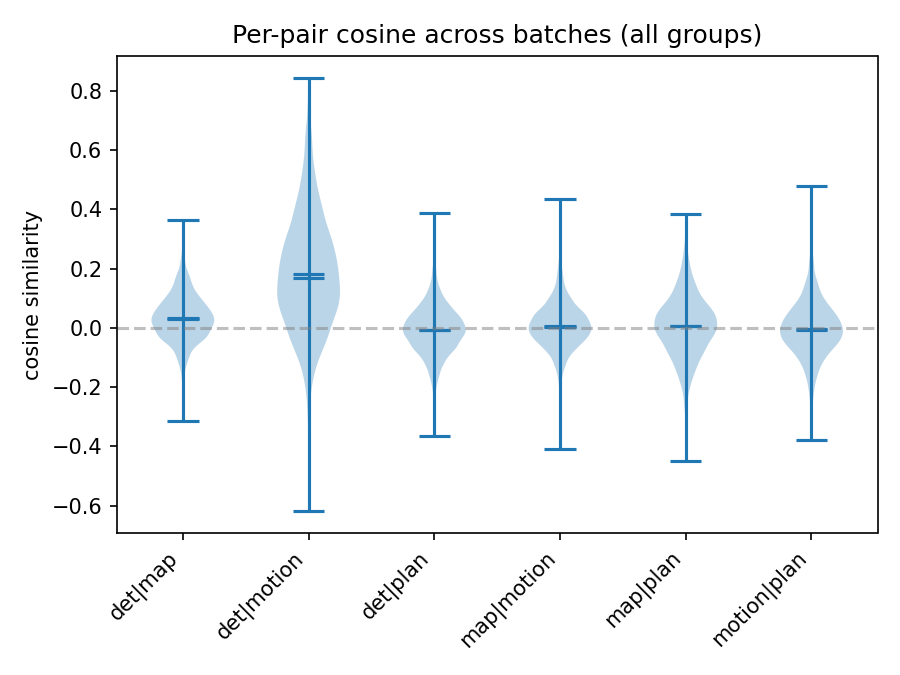

== 3ep  (iter_5274, real_epoch=3.00)  ckpt_3ep/conflict/cosine_violin.png ==


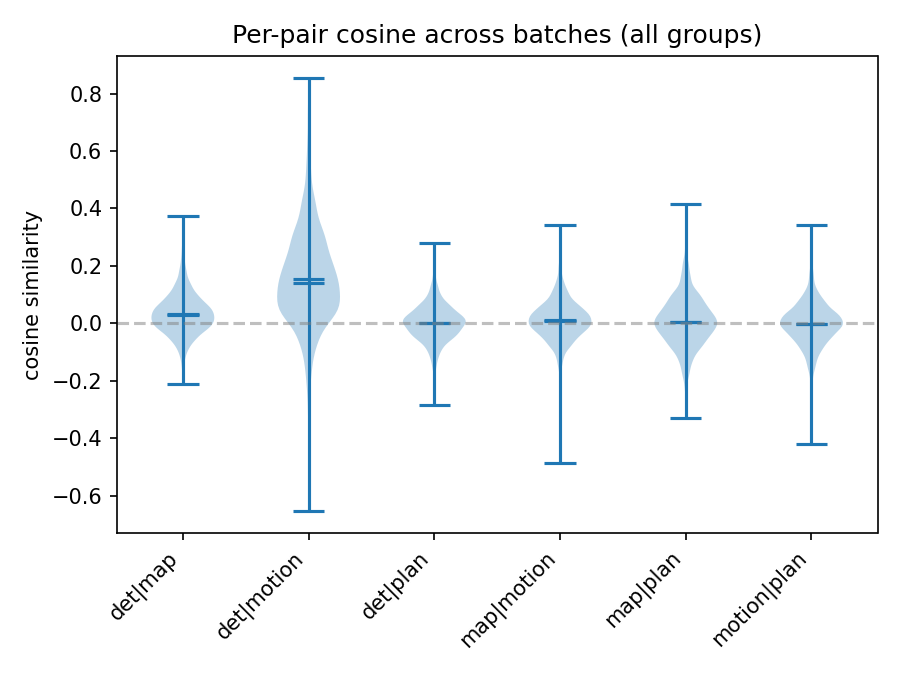

== 9ep  (iter_15822, real_epoch=9.00)  ckpt_9ep/conflict/cosine_violin.png ==


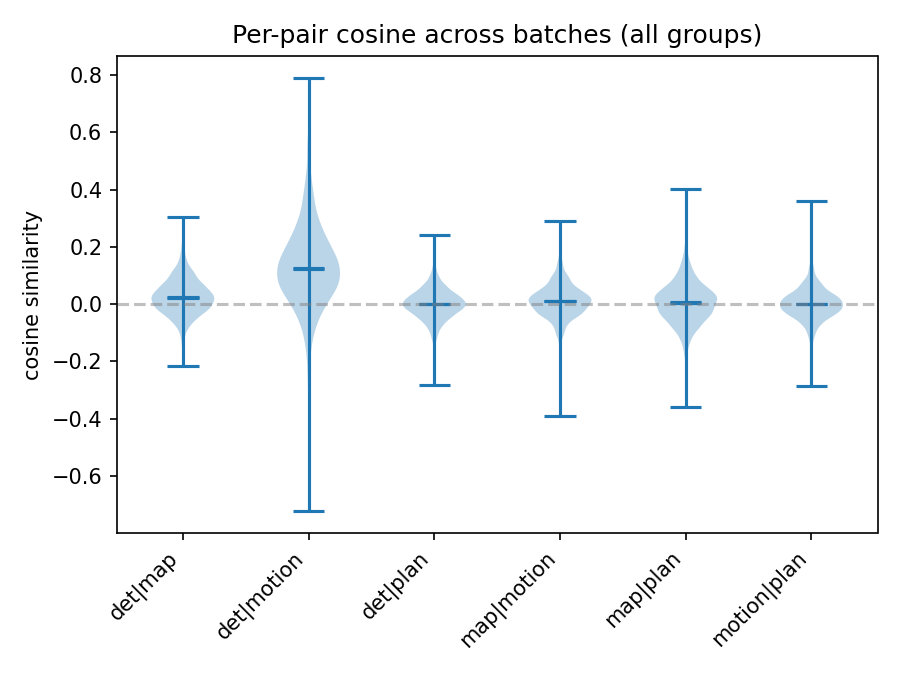

== 18ep  (iter_31644, real_epoch=18.00)  ckpt_18ep/conflict/cosine_violin.png ==


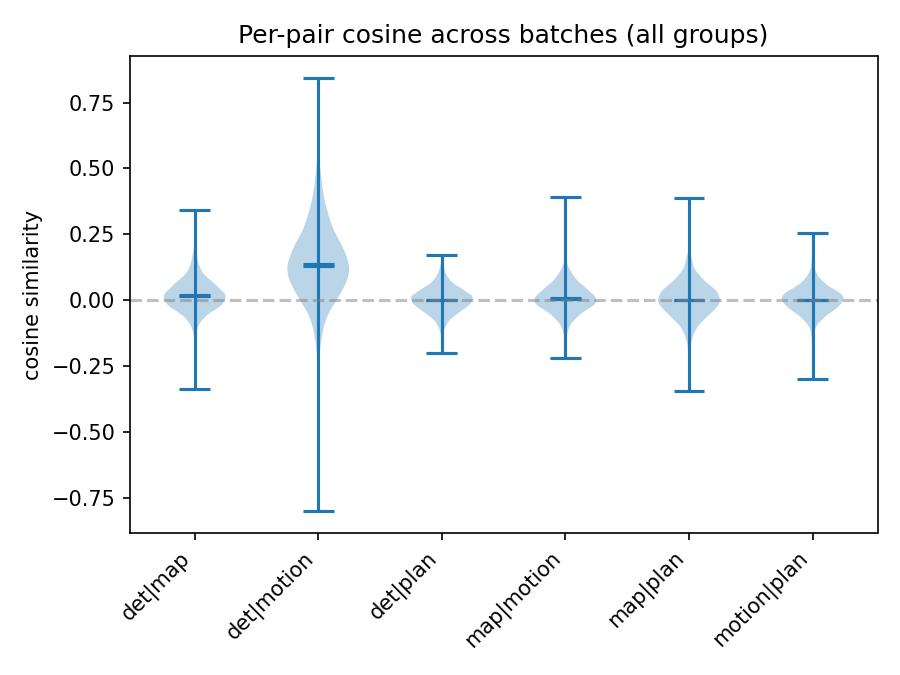

In [9]:
def show_pngs(rel_path):
    for tag, it, ep, p in CKPTS:
        png = p / rel_path
        if png.exists():
            print(f'== {tag}  (iter_{it}, real_epoch={ep:.2f})  {png.relative_to(RESULTS_ROOT)} ==')
            display(Image(filename=str(png)))
        else:
            print(f'== {tag}  (missing: {png.name}) ==')

print('### shared groups')
show_pngs('conflict/cosine_violin.png')

### inter-GNN layer groups
== 1ep  (iter_1758, real_epoch=1.00)  ckpt_1ep/layer_conflict/cosine_violin.png ==


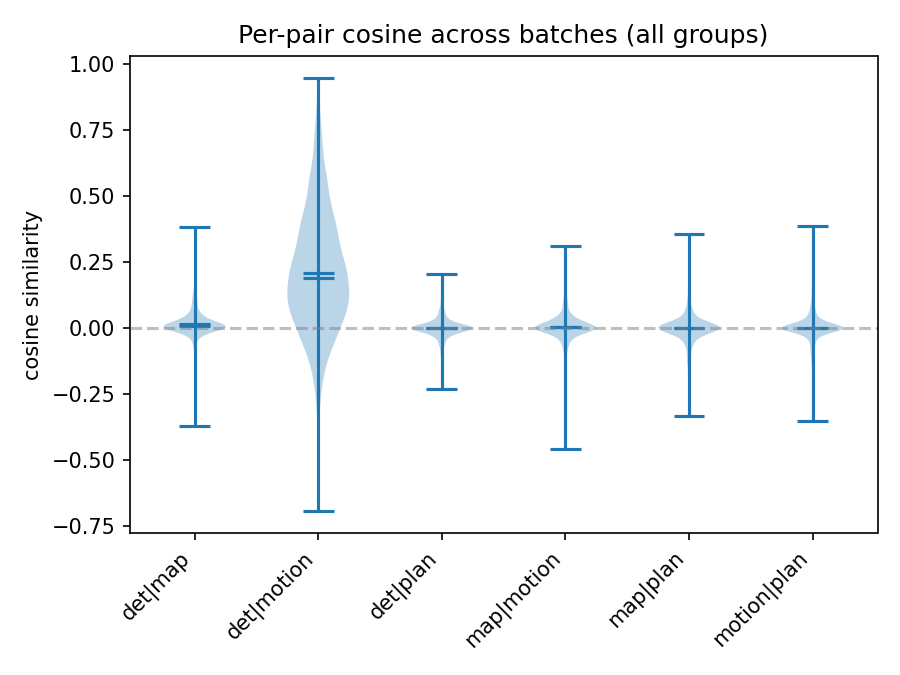

== 3ep  (iter_5274, real_epoch=3.00)  ckpt_3ep/layer_conflict/cosine_violin.png ==


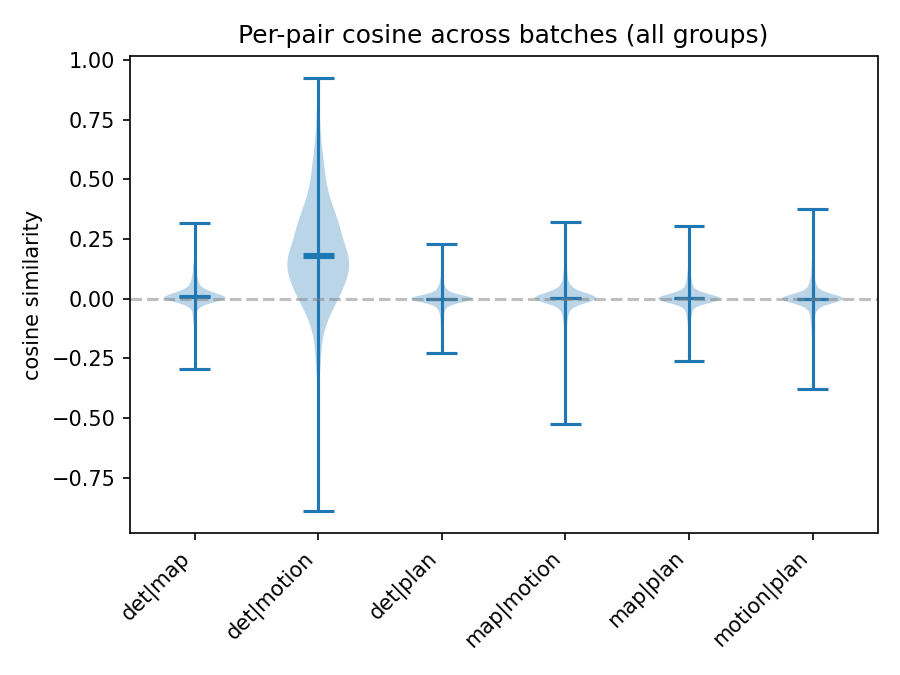

== 9ep  (iter_15822, real_epoch=9.00)  ckpt_9ep/layer_conflict/cosine_violin.png ==


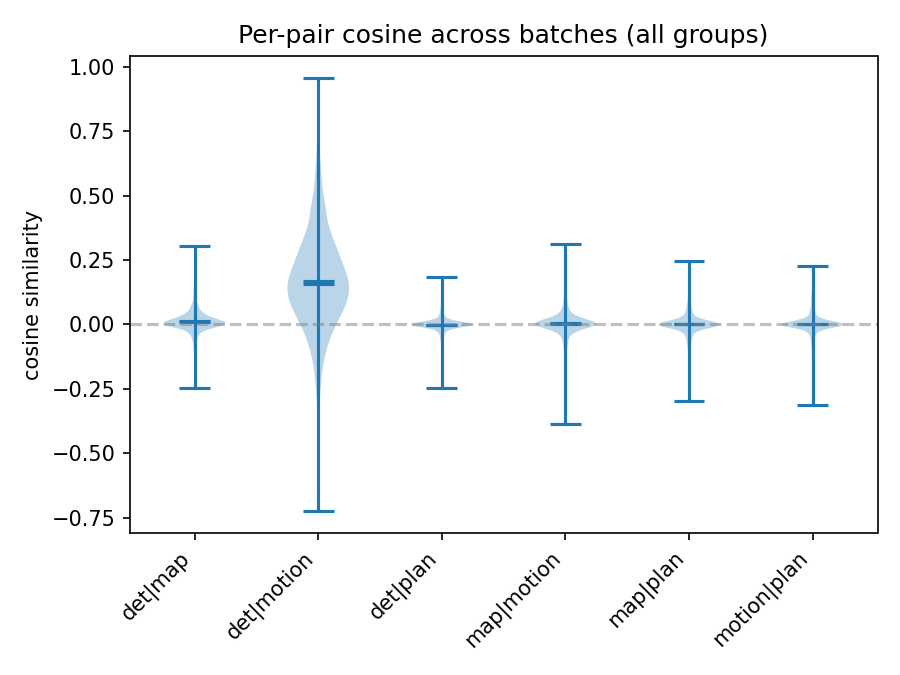

== 18ep  (iter_31644, real_epoch=18.00)  ckpt_18ep/layer_conflict/cosine_violin.png ==


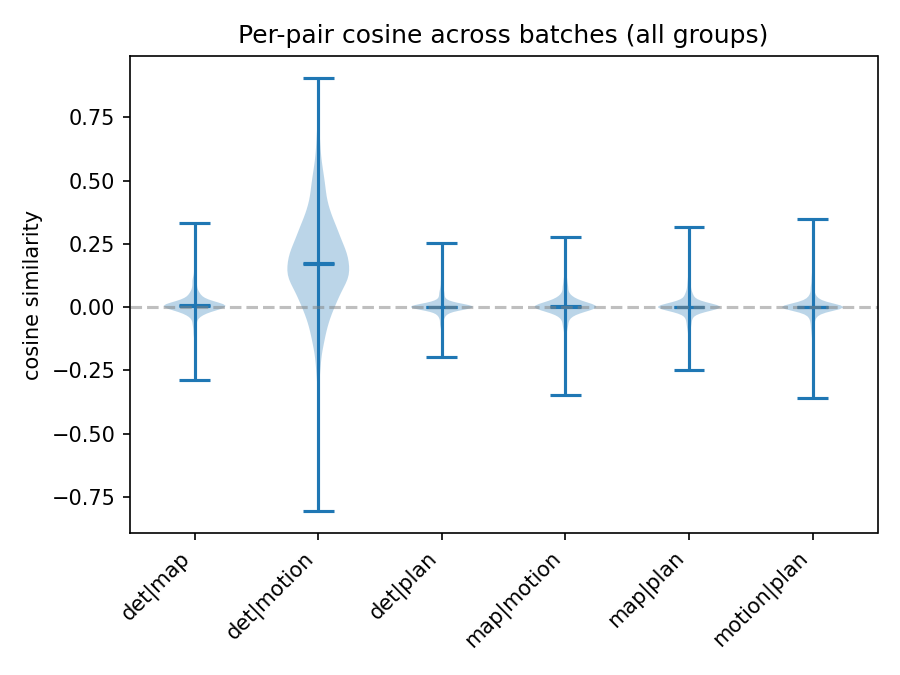

In [10]:
print('### inter-GNN layer groups')
show_pngs('layer_conflict/cosine_violin.png')

## 4. 1-step probe — source → target transfer (`M3`)

### 4.1 무엇을 보는가
한 batch 에서 source task `s` 의 gradient 방향으로 (`normalized` variant: 단위 norm 으로 정규화) `θ_s ← θ_s − α·ĝ_s` 한 번 update 한 뒤, 그 step 이 target task `t` 의 loss 를 얼마나 줄였는가/늘렸는가 (`Δ_st = L_t(θ_s) − L_t(θ_0)`).

### 4.2 어떻게 읽는가 (heatmap)
- 색 = `Δloss`. **파랑 ⇒ 도움 (Δ<0)**, **빨강 ⇒ 해침 (Δ>0)**.
- **대각선이 파랑**이어야 정상 (self-step 이 self-loss 를 줄임). 빨강이면 step 크기/방향 문제.
- **비대각의 비대칭** — `Δ_{a→b} ≠ Δ_{b→a}` 이면 협력/간섭이 단방향. e.g. det→plan 은 도움, plan→det 은 무관.
- 색이 거의 흰색이면 그 source 의 update 가 그 target 에 영향이 없다 — coupling 약함.
- `variant='normalized'` 를 쓰면 "방향만" 의 효과로 정리되어 비교가 깨끗하다.

### 4.3 두 시각: layer 축 vs epoch 축
- §4.1 셀 `(ckpt 고정 × layer 6개)` — 같은 시점에서 어느 layer 가 가장 strong transfer/interference 를 만드는가.
- §4.2 셀 `(layer 고정 × ckpt 5개)` — 같은 layer 가 학습이 진행되며 어떻게 변하는가.
- §4.3 셀 `helpful_rate` — "비대각 Δ<0 가 batch 의 몇 % 인가" 의 layer × epoch 추세 (방향 일관성).

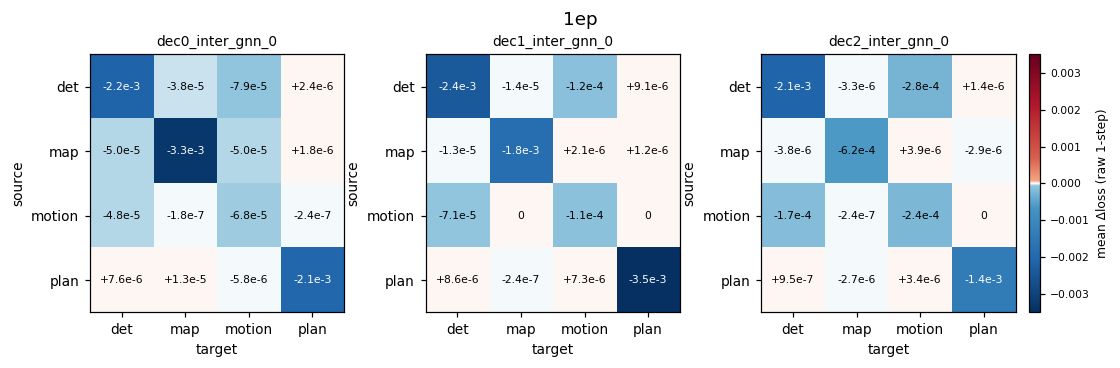

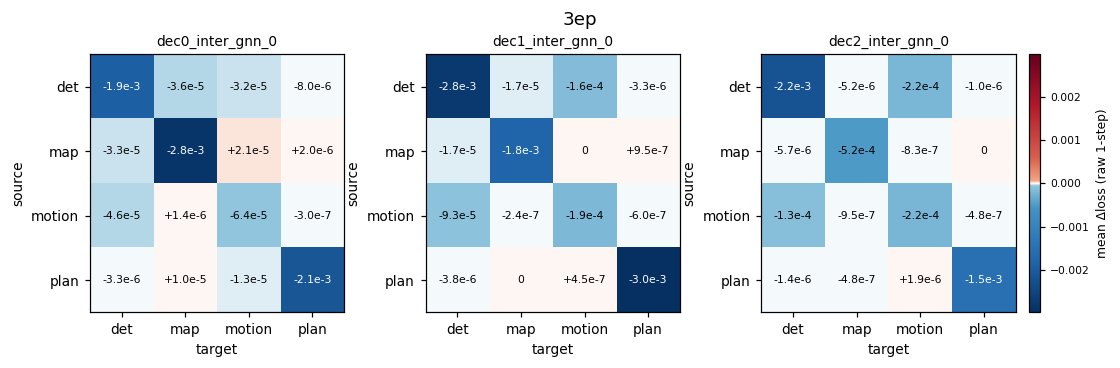

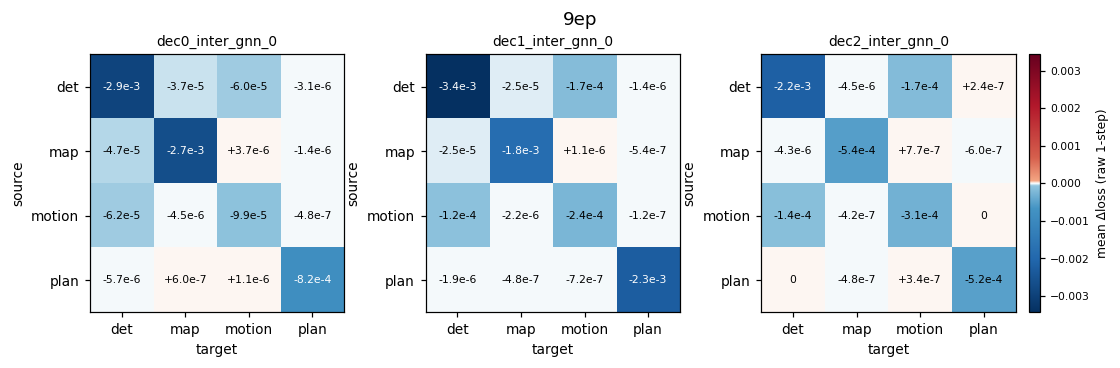

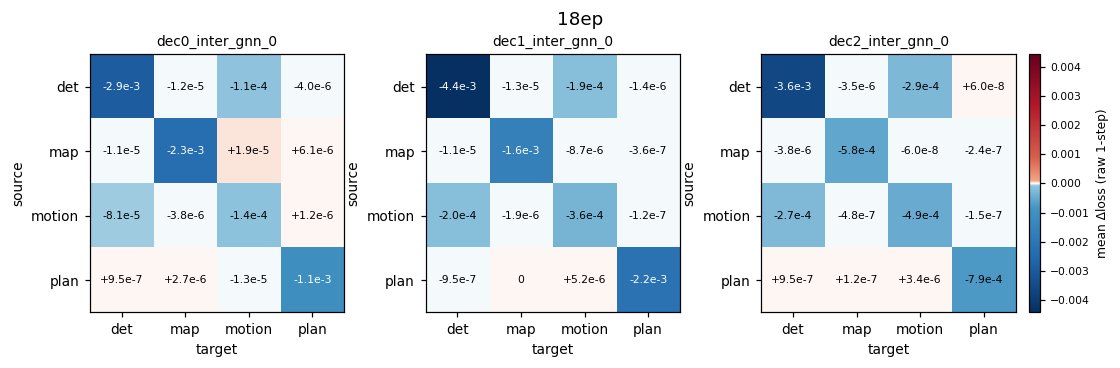

In [11]:
# Narrow-white diverging cmap: small +/- values stay visibly red/blue.
# 원본 phase2_v3 노트북과 동일한 RdBu_r 톤. WHITE_FRAC 으로 가운데 흰색 폭 조정.
WHITE_FRAC = 0.01   # 흰색 영역 폭 (0~0.5). vmax 의 약 2% 가 흰색.
NARROW_RDBU = LinearSegmentedColormap.from_list('RdBu_r_narrow', [
    (0.00,              '#053061'),
    (0.20,              '#2166ac'),
    (0.40,              '#4393c3'),
    (0.50 - WHITE_FRAC, '#92c5de'),
    (0.50,              '#ffffff'),
    (0.50 + WHITE_FRAC, '#f4a582'),
    (0.60,              '#d6604d'),
    (0.80,              '#b2182b'),
    (1.00,              '#67001f'),
], N=512)
TEXT_FLIP = 0.20  # |v|/vlim 이 이 값보다 크면 흰색 글씨


def probe_matrix(pr, variant=DEFAULT_PROBE_VARIANT, other=None):
    """Mean Δloss per (source, target).

    For pcgrad_* variants ``other_task`` slices the projection target;
    pass ``other=<task>`` to pick a specific slice (default: average over
    all `other` tasks except those equal to source).
    """
    if pr.empty:
        return pd.DataFrame()
    sub = pr[(pr['variant'] == variant) & (pr['steps'] == 1)]
    if sub.empty:
        sub = pr[pr['steps'] == 1]
    if other is not None and 'other_task' in sub.columns:
        sub = sub[sub['other_task'] == other]
    g = (sub.groupby(['source_task', 'target_task'])['delta']
             .median().reset_index())
    return (g.pivot(index='source_task', columns='target_task', values='delta')
             .reindex(index=TASK_ORDER, columns=TASK_ORDER))


def _fmt_short(v):
    """짧은 +/- exponent 포맷 (셀 안 글자 겹침 방지)."""
    if not np.isfinite(v):
        return ''
    if abs(v) < 1e-12:
        return '0'
    s = f'{v:+.1e}'
    return s.replace('e-0', 'e-').replace('e+0', 'e+')


def draw_matrix(ax, mat, title, vmax=None):
    if mat.empty:
        ax.set_title(title + ' (empty)', fontsize=9); ax.axis('off'); return None
    A = mat.values
    if vmax is None:
        vmax = np.nanmax(np.abs(A)) or 1e-12
    im = ax.imshow(A, cmap=NARROW_RDBU, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(len(TASK_ORDER))); ax.set_xticklabels(TASK_ORDER, fontsize=9)
    ax.set_yticks(range(len(TASK_ORDER))); ax.set_yticklabels(TASK_ORDER, fontsize=9)
    ax.set_xlabel('target', fontsize=9); ax.set_ylabel('source', fontsize=9)
    ax.grid(False)
    for i in range(A.shape[0]):
        for j in range(A.shape[1]):
            v = A[i, j]
            txt = _fmt_short(v)
            if not txt:
                continue
            ax.text(j, i, txt, ha='center', va='center', fontsize=7,
                    color='white' if abs(v) > TEXT_FLIP * vmax else 'black')
    ax.set_title(title, fontsize=9)
    return im


def _add_external_colorbar(fig, im, axes, label):
    """Colorbar 를 subplot 영역 밖 우측 별도 axes 로 배치 (matrix 와 겹치지 않게)."""
    fig.subplots_adjust(left=0.05, right=0.90, top=0.85, bottom=0.14, wspace=0.32)
    pos_first = axes[0].get_position()
    pos_last  = axes[-1].get_position()
    cax = fig.add_axes([pos_last.x1 + 0.012, pos_first.y0,
                        0.010, pos_first.y1 - pos_first.y0])
    cb = fig.colorbar(im, cax=cax)
    cb.set_label(label, fontsize=8)
    cb.ax.tick_params(labelsize=7)


# 4.1 ckpt 한 칸 × layer 6칸 — 같은 시점에서 layer 차이
for tag, it, ep, p in CKPTS:
    sub = probe_per_batch[probe_per_batch['checkpoint'] == tag]
    if sub.empty:
        continue
    layers = [L for L in TARGET_LAYERS if L in sub['layer'].unique()]
    if not layers:
        continue
    ncols = len(layers)
    fig, axes = plt.subplots(1, ncols, figsize=(3.3 * ncols, 3.3), squeeze=False)
    axes = axes[0]
    vmax_g = max(
        (np.nanmax(np.abs(probe_matrix(sub[sub['layer'] == L]).values))
         for L in layers if not probe_matrix(sub[sub['layer'] == L]).empty),
        default=1e-12)
    im = None
    for ax, L in zip(axes, layers):
        im_new = draw_matrix(ax, probe_matrix(sub[sub['layer'] == L]), L, vmax=vmax_g)
        if im_new is not None:
            im = im_new
    plt.suptitle(f'{tag}', y=0.97)
    if im is not None:
        _add_external_colorbar(fig, im, axes, 'mean Δloss (raw 1-step)')
    plt.show()

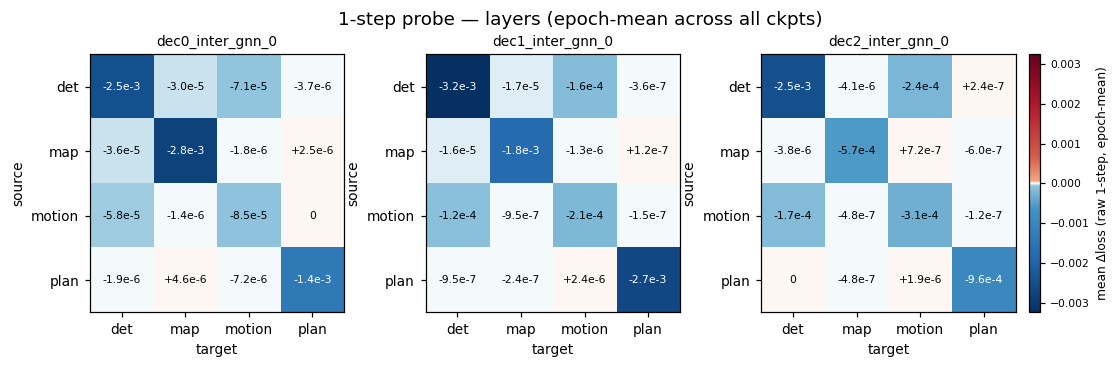

In [12]:
# 4.1b layer 6칸 — 모든 epoch 평균 (= ckpt 축에 대한 평균)
# §4.1 은 한 ckpt 시점만 보고, §4.2 는 한 layer 의 epoch 변화를 본다.
# 여기서는 layer 별로 학습 전체 (모든 ckpt) 를 평균해서 "정상상태" source→target 구조를 본다.
layers = [L for L in TARGET_LAYERS if L in probe_per_batch['layer'].unique()]
if layers:
    ncols = len(layers)
    fig, axes = plt.subplots(1, ncols, figsize=(3.3 * ncols, 3.3), squeeze=False)
    axes = axes[0]
    vmax_g = max(
        (np.nanmax(np.abs(probe_matrix(probe_per_batch[probe_per_batch['layer'] == L]).values))
         for L in layers if not probe_matrix(probe_per_batch[probe_per_batch['layer'] == L]).empty),
        default=1e-12)
    im = None
    for ax, L in zip(axes, layers):
        im_new = draw_matrix(
            ax, probe_matrix(probe_per_batch[probe_per_batch['layer'] == L]),
            L, vmax=vmax_g)
        if im_new is not None:
            im = im_new
    plt.suptitle('1-step probe — layers (epoch-mean across all ckpts)', y=0.97)
    if im is not None:
        _add_external_colorbar(fig, im, axes, 'mean Δloss (raw 1-step, epoch-mean)')
    plt.show()

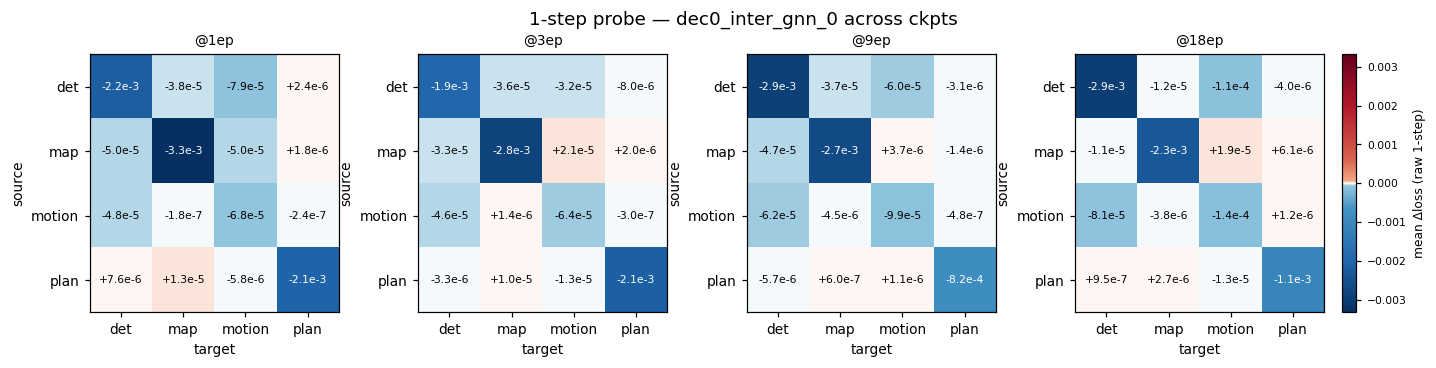

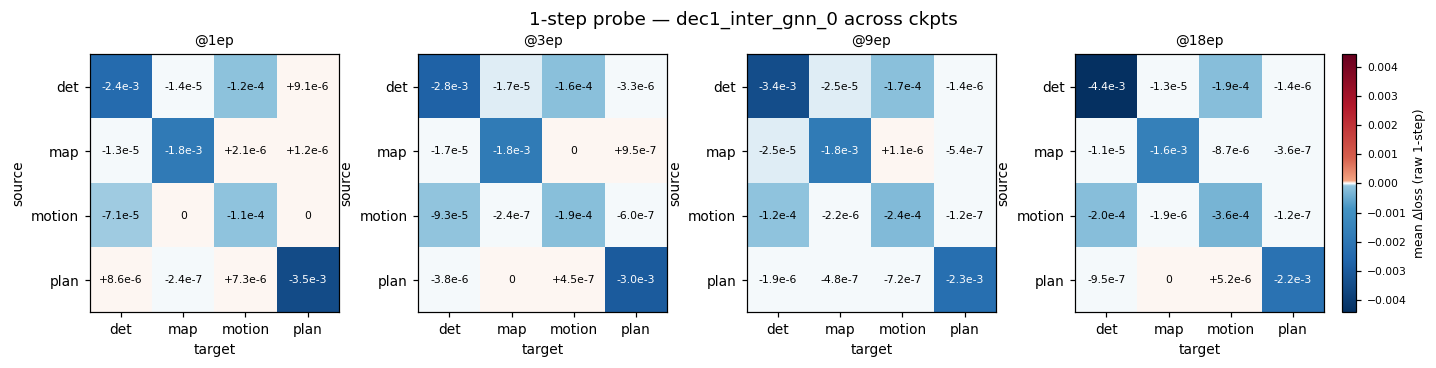

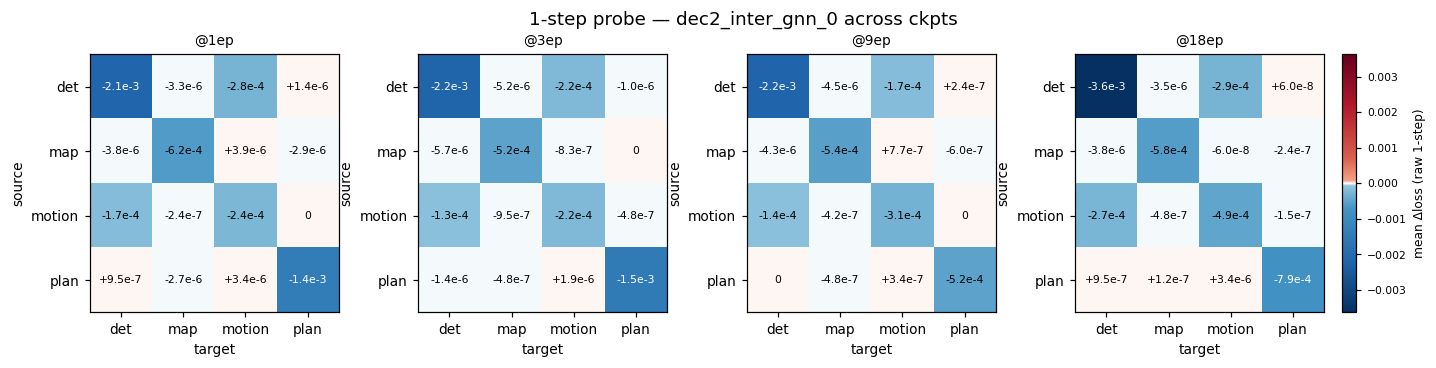

In [13]:
# 4.2 layer 한 칸 × ckpt 칸 — 같은 layer 가 학습 따라 어떻게 변하는가
for L in TARGET_LAYERS:
    sub = probe_per_batch[probe_per_batch['layer'] == L]
    if sub.empty:
        continue
    ckpts = [t for (t, _, _, _) in CKPTS if t in sub['checkpoint'].unique()]
    if not ckpts:
        continue
    ncols = len(ckpts)
    fig, axes = plt.subplots(1, ncols, figsize=(3.3 * ncols, 3.3), squeeze=False)
    axes = axes[0]
    vmax_g = max(
        (np.nanmax(np.abs(probe_matrix(sub[sub['checkpoint'] == c]).values))
         for c in ckpts if not probe_matrix(sub[sub['checkpoint'] == c]).empty),
        default=1e-12)
    im = None
    for ax, c in zip(axes, ckpts):
        im_new = draw_matrix(ax, probe_matrix(sub[sub['checkpoint'] == c]), f'@{c}', vmax=vmax_g)
        if im_new is not None:
            im = im_new
    plt.suptitle(f'1-step probe — {L} across ckpts', y=0.97)
    if im is not None:
        _add_external_colorbar(fig, im, axes, 'mean Δloss (raw 1-step)')
    plt.show()

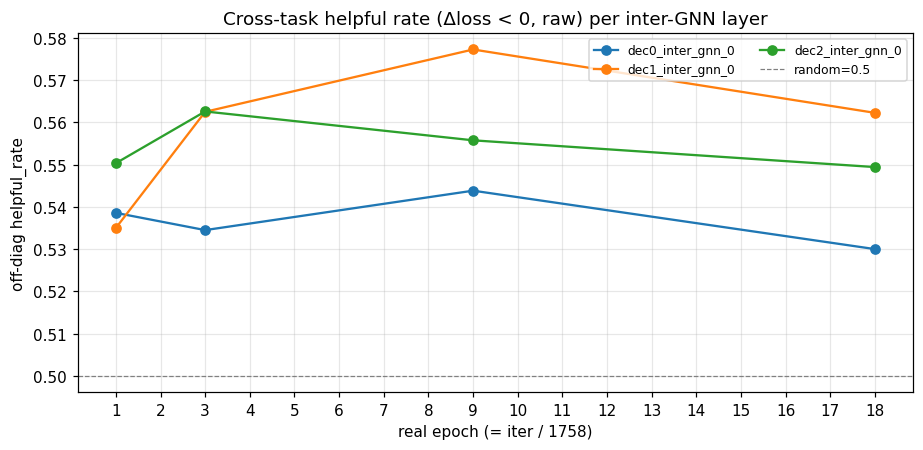

In [14]:
# 4.3 Off-diagonal helpful_rate (= P[Δ<0 | source!=target]) by layer over training
if not probe_per_batch.empty:
    pr = probe_per_batch[
        (probe_per_batch['variant'] == DEFAULT_PROBE_VARIANT)
        & (probe_per_batch['steps'] == 1)
        & (probe_per_batch['source_task'] != probe_per_batch['target_task'])
    ].copy()
    pr['helpful'] = (pr['delta'] < 0).astype(int)
    rate = (pr.groupby(['epoch', 'iter', 'checkpoint', 'layer'])['helpful']
              .mean().reset_index(name='helpful_rate'))
    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    for L in TARGET_LAYERS:
        ldf = rate[rate['layer'] == L].sort_values('epoch')
        if ldf.empty:
            continue
        ax.plot(ldf['epoch'], ldf['helpful_rate'], marker='o', label=L)
    ax.axhline(0.5, color='gray', ls='--', lw=0.8, label='random=0.5')
    ax.set_xlabel('real epoch (= iter / 1758)'); ax.set_ylabel('off-diag helpful_rate')
    ax.set_title('Cross-task helpful rate (Δloss < 0, raw) per inter-GNN layer')
    ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2)
    set_epoch_xaxis(ax, step=1)
    plt.tight_layout(); plt.show()

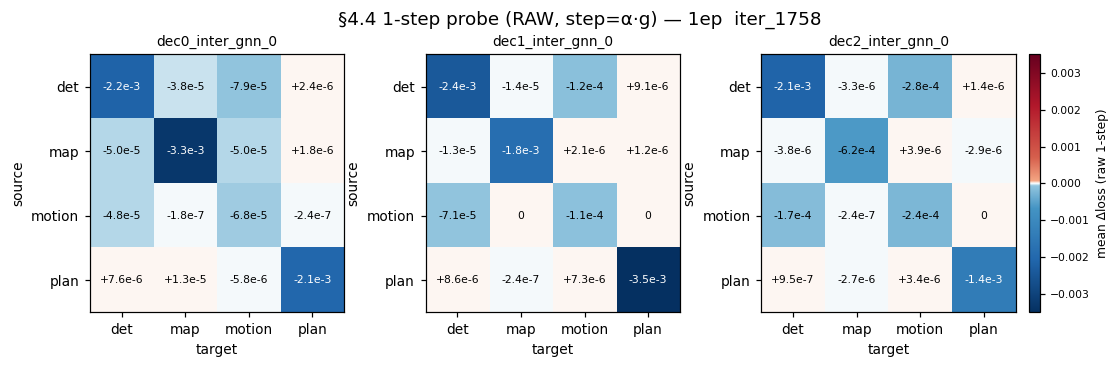

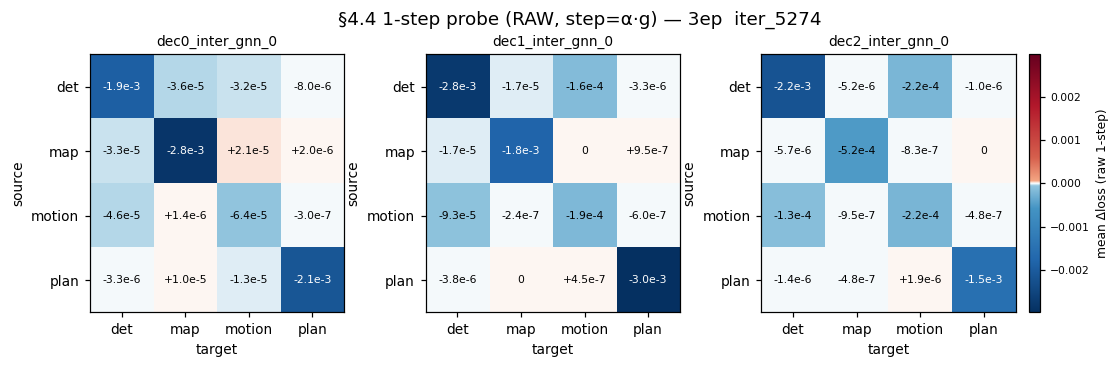

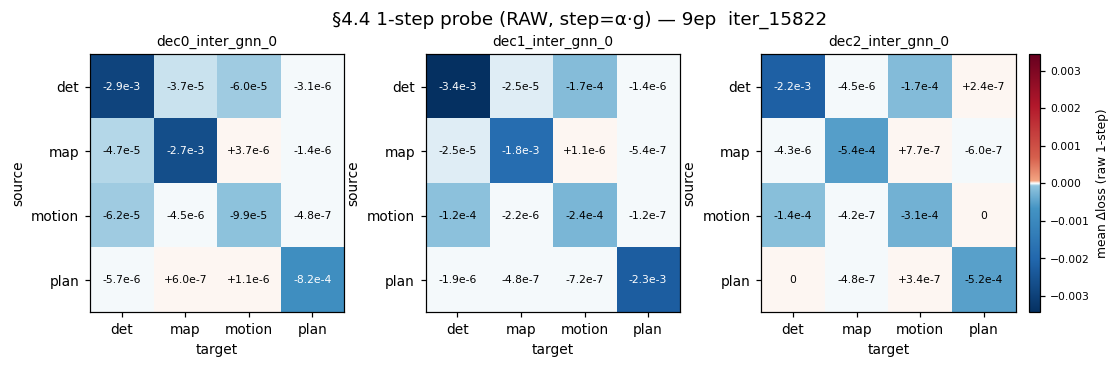

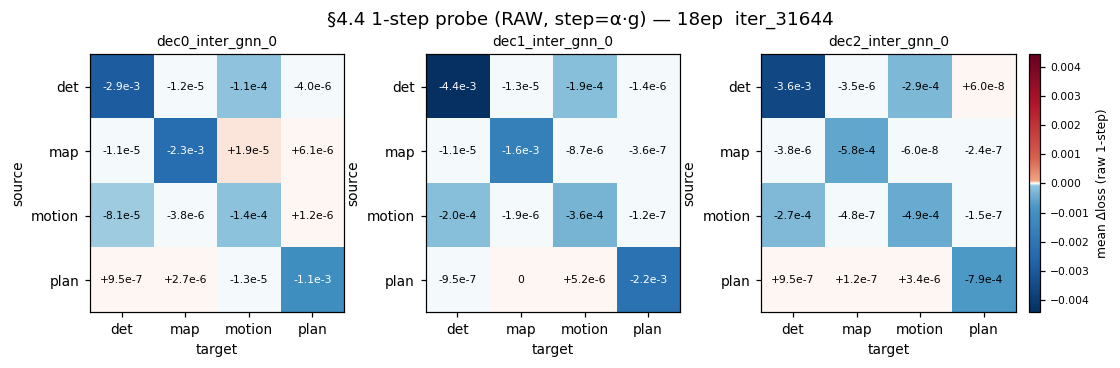

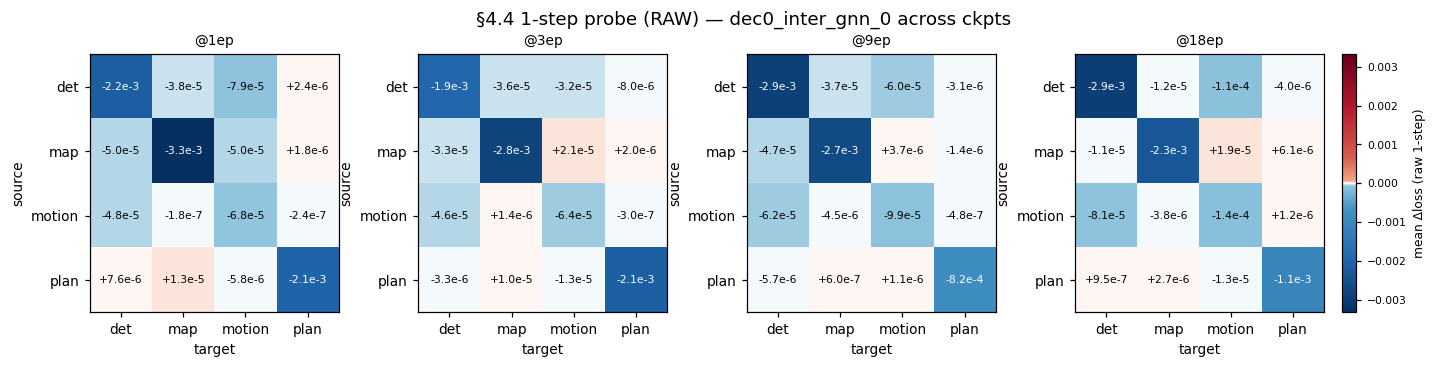

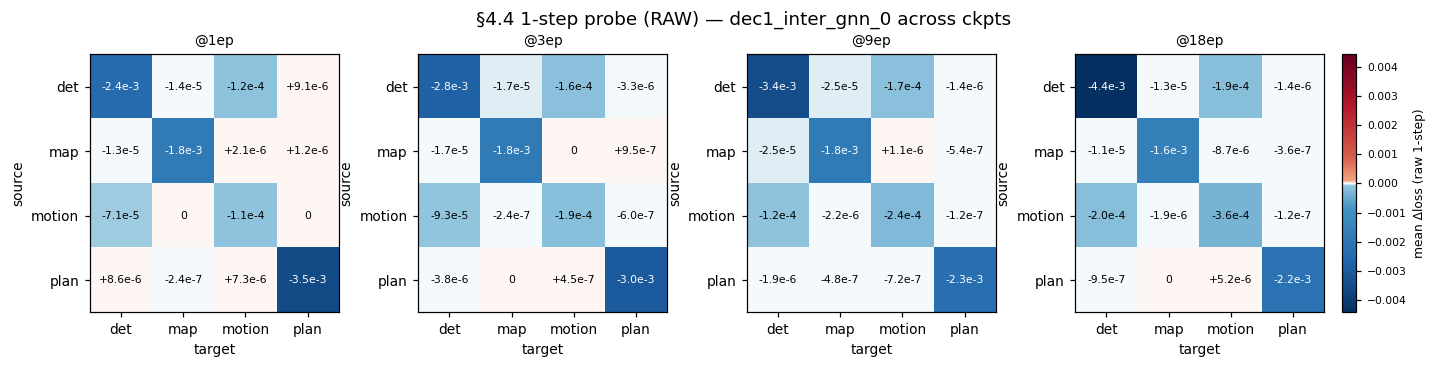

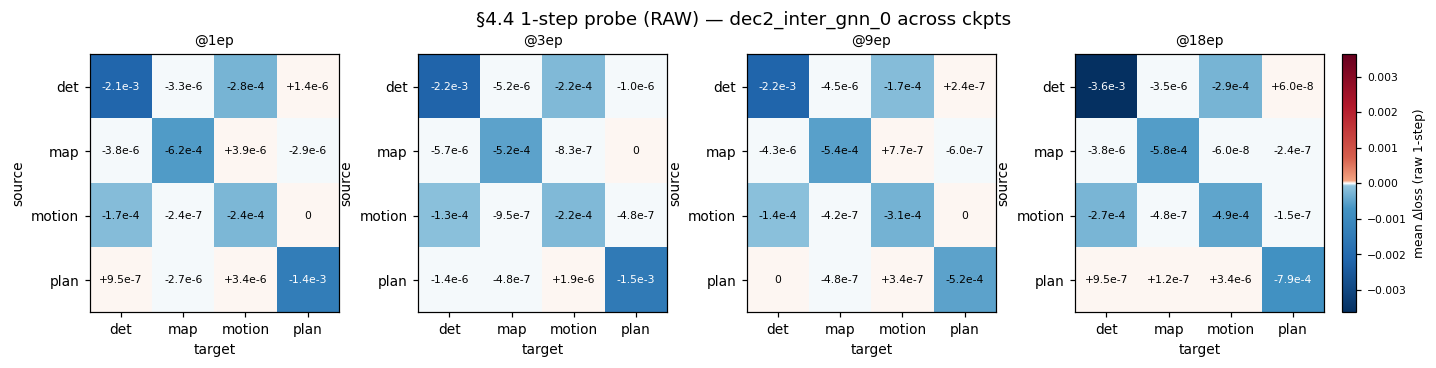

In [15]:
# §4.4 1-step probe — RAW variant (step = α·g, no normalization)
#
# Why a separate view: normalized variant 의 1차항은 -α·cos·‖g_B‖ 라 cosine 부호를
# 직접 반영하지만, step size 는 α/‖g‖ 이라 ‖g‖ 작은 layer 에서 trust region 깨짐
# (= dec4/dec5 의 *FLIP* artifact 가 normalized 에서만 발생). RAW 는 step = α·g
# 이므로 실제 SGD 한 step 의 effect 에 가까움. dec4/dec5 부호가 normalized 와
# 다르게 나오면, 그건 measurement artifact 였다는 직접 증거.
#
# 동일 구조: §4.1 (ckpt 한 칸 × layer 6칸), §4.2 (layer 한 칸 × ckpt 칸).

# layout A: ckpt 한 칸 × layer 6칸
for tag, it, ep, p in CKPTS:
    sub = probe_per_batch[probe_per_batch['checkpoint'] == tag]
    if sub.empty:
        continue
    layers = [L for L in TARGET_LAYERS if L in sub['layer'].unique()]
    if not layers:
        continue
    ncols = len(layers)
    fig, axes = plt.subplots(1, ncols, figsize=(3.3 * ncols, 3.3), squeeze=False)
    axes = axes[0]
    vmax_g = max(
        (np.nanmax(np.abs(probe_matrix(sub[sub['layer'] == L], variant='raw').values))
         for L in layers if not probe_matrix(sub[sub['layer'] == L], variant='raw').empty),
        default=1e-12)
    im = None
    for ax, L in zip(axes, layers):
        im_new = draw_matrix(ax, probe_matrix(sub[sub['layer'] == L], variant='raw'), L, vmax=vmax_g)
        if im_new is not None:
            im = im_new
    plt.suptitle(f'§4.4 1-step probe (RAW, step=α·g) — {tag}  iter_{it}', y=0.97)
    if im is not None:
        _add_external_colorbar(fig, im, axes, 'mean Δloss (raw 1-step)')
    plt.show()

# layout B: layer 한 칸 × ckpt 칸
for L in TARGET_LAYERS:
    sub = probe_per_batch[probe_per_batch['layer'] == L]
    if sub.empty:
        continue
    ckpts_here = [t for (t, _, _, _) in CKPTS if t in sub['checkpoint'].unique()]
    if not ckpts_here:
        continue
    ncols = len(ckpts_here)
    fig, axes = plt.subplots(1, ncols, figsize=(3.3 * ncols, 3.3), squeeze=False)
    axes = axes[0]
    vmax_g = max(
        (np.nanmax(np.abs(probe_matrix(sub[sub['checkpoint'] == c], variant='raw').values))
         for c in ckpts_here if not probe_matrix(sub[sub['checkpoint'] == c], variant='raw').empty),
        default=1e-12)
    im = None
    for ax, c in zip(axes, ckpts_here):
        im_new = draw_matrix(ax, probe_matrix(sub[sub['checkpoint'] == c], variant='raw'), f'@{c}', vmax=vmax_g)
        if im_new is not None:
            im = im_new
    plt.suptitle(f'§4.4 1-step probe (RAW) — {L} across ckpts', y=0.97)
    if im is not None:
        _add_external_colorbar(fig, im, axes, 'mean Δloss (raw 1-step)')
    plt.show()


### 4.5 PCGrad variant heatmaps — `pcgrad_strict` & `pcgrad_normpreserved`

PCGrad variants 는 source gradient 를 `other_task` gradient 의 음방향 성분만큼 깎아내고
그 결과로 step 한다. 따라서 4×4 affinity matrix 가 `other_task` 마다 하나씩 정의된다 (`raw`
에서는 `other_task='_none'`).

- `pcgrad_strict`: projection 후 그대로 step → magnitude 가 `√(1−cos²)` 만큼 줄어듦.
- `pcgrad_normpreserved`: 같은 방향이지만 `‖g_source‖` 로 rescale → **방향-only effect** 분리.
- 차이 `(raw − normpreserved)` ≈ 방향 변화 효과, `(strict − normpreserved)` ≈ 순수 shrinkage 효과.

여기서는 각 epoch × layer 에서 (`other` × source → target) cube 를 한 줄씩 풀어 본다.
셀 한 칸 = 한 `other_task` 에 대한 4×4 matrix (source vs target).

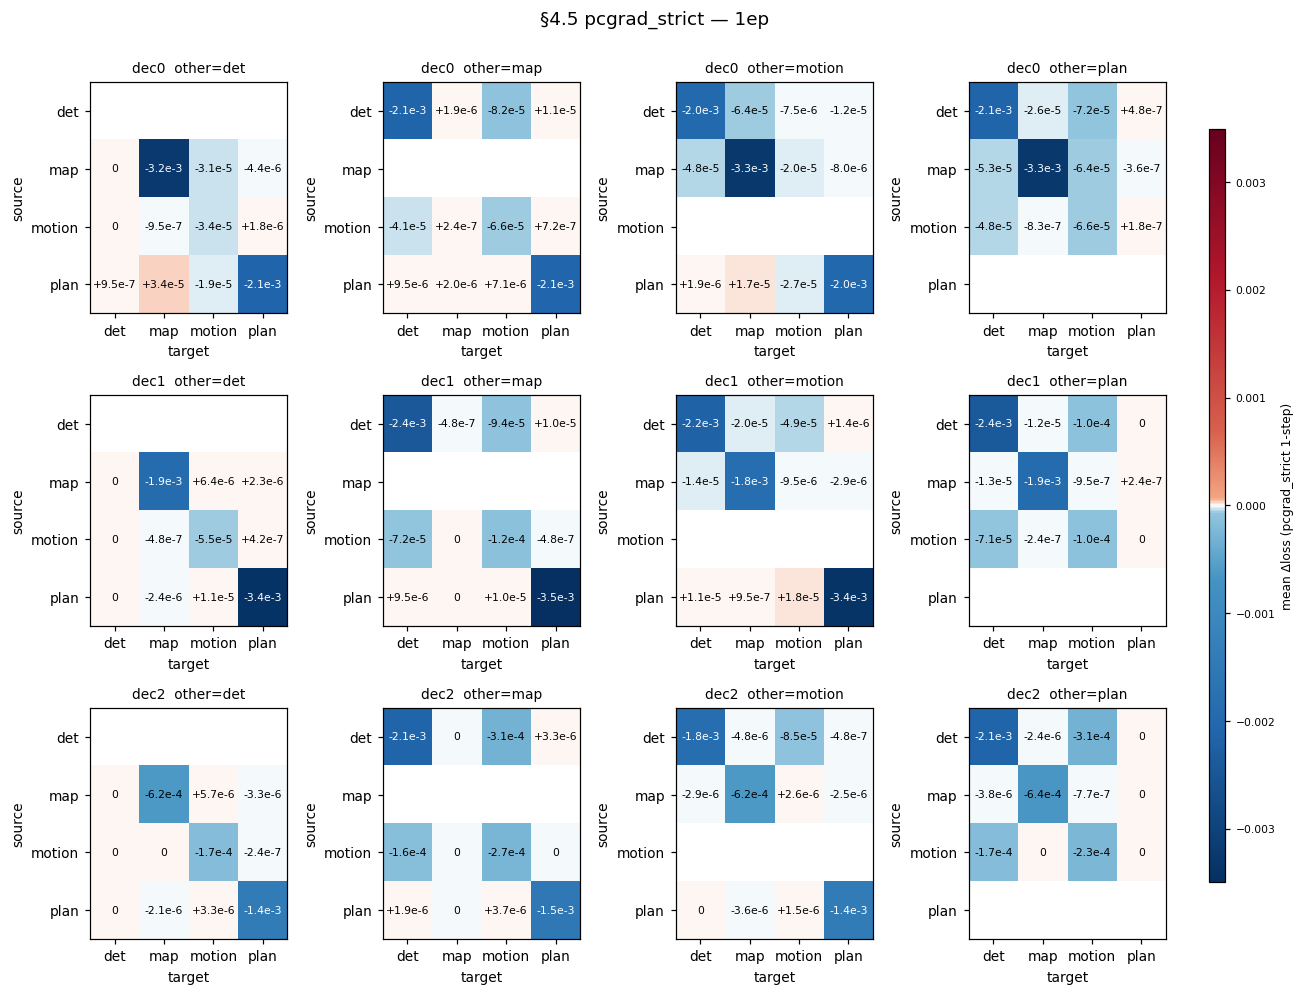

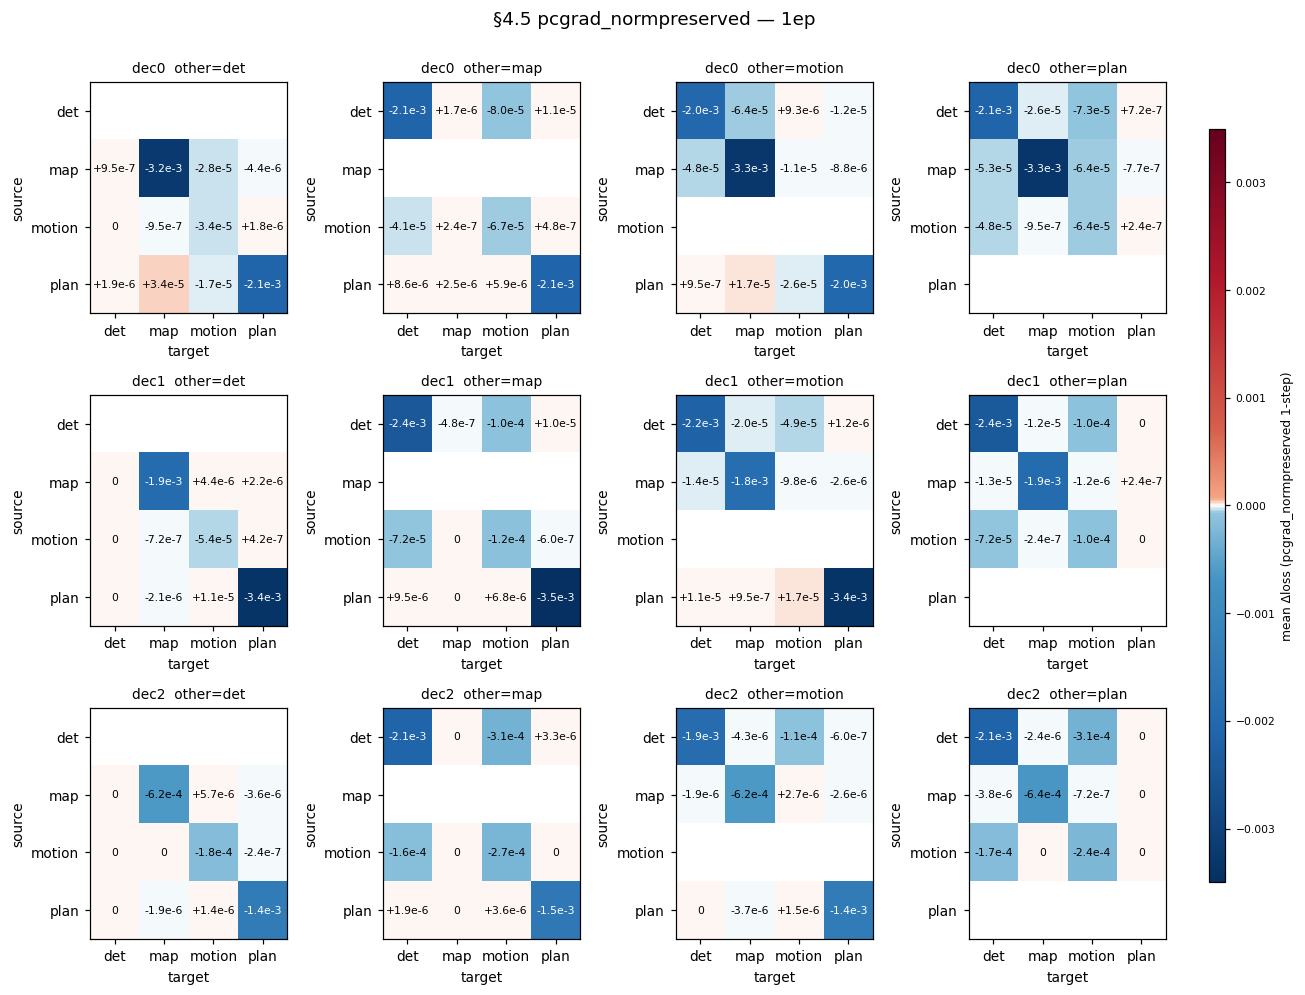

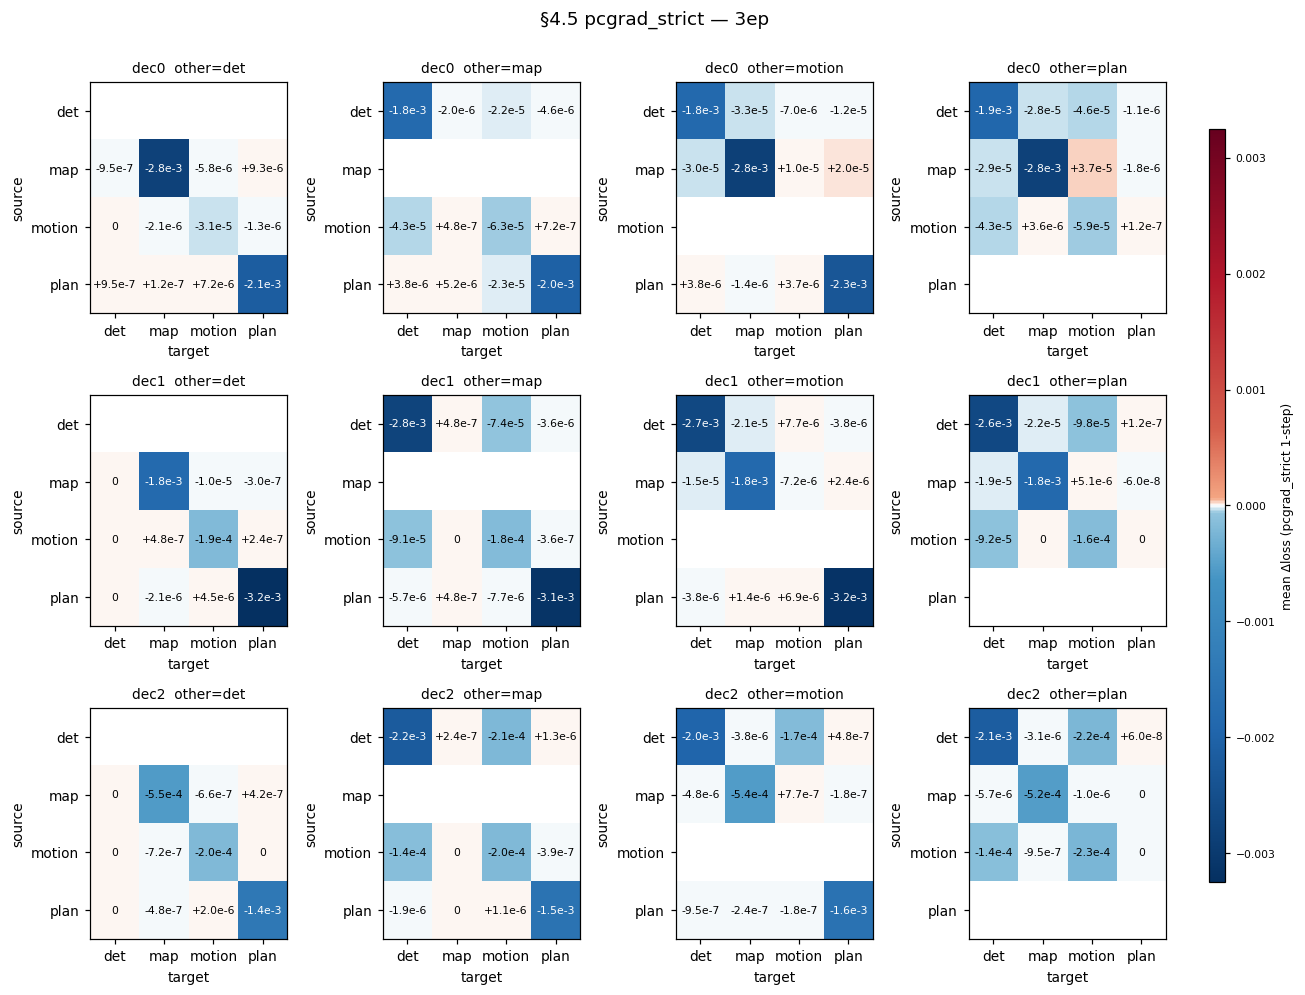

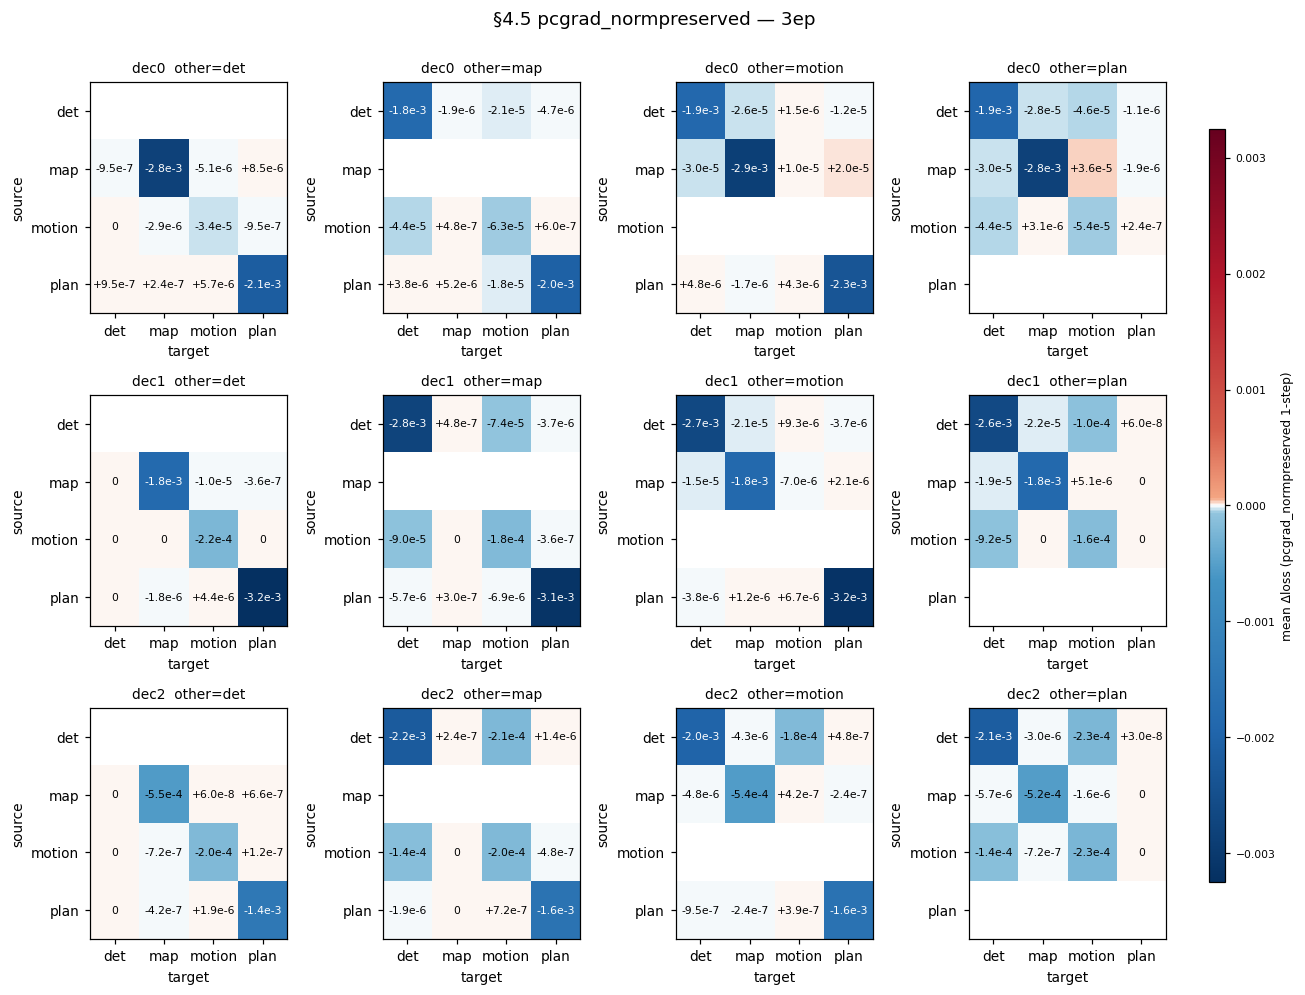

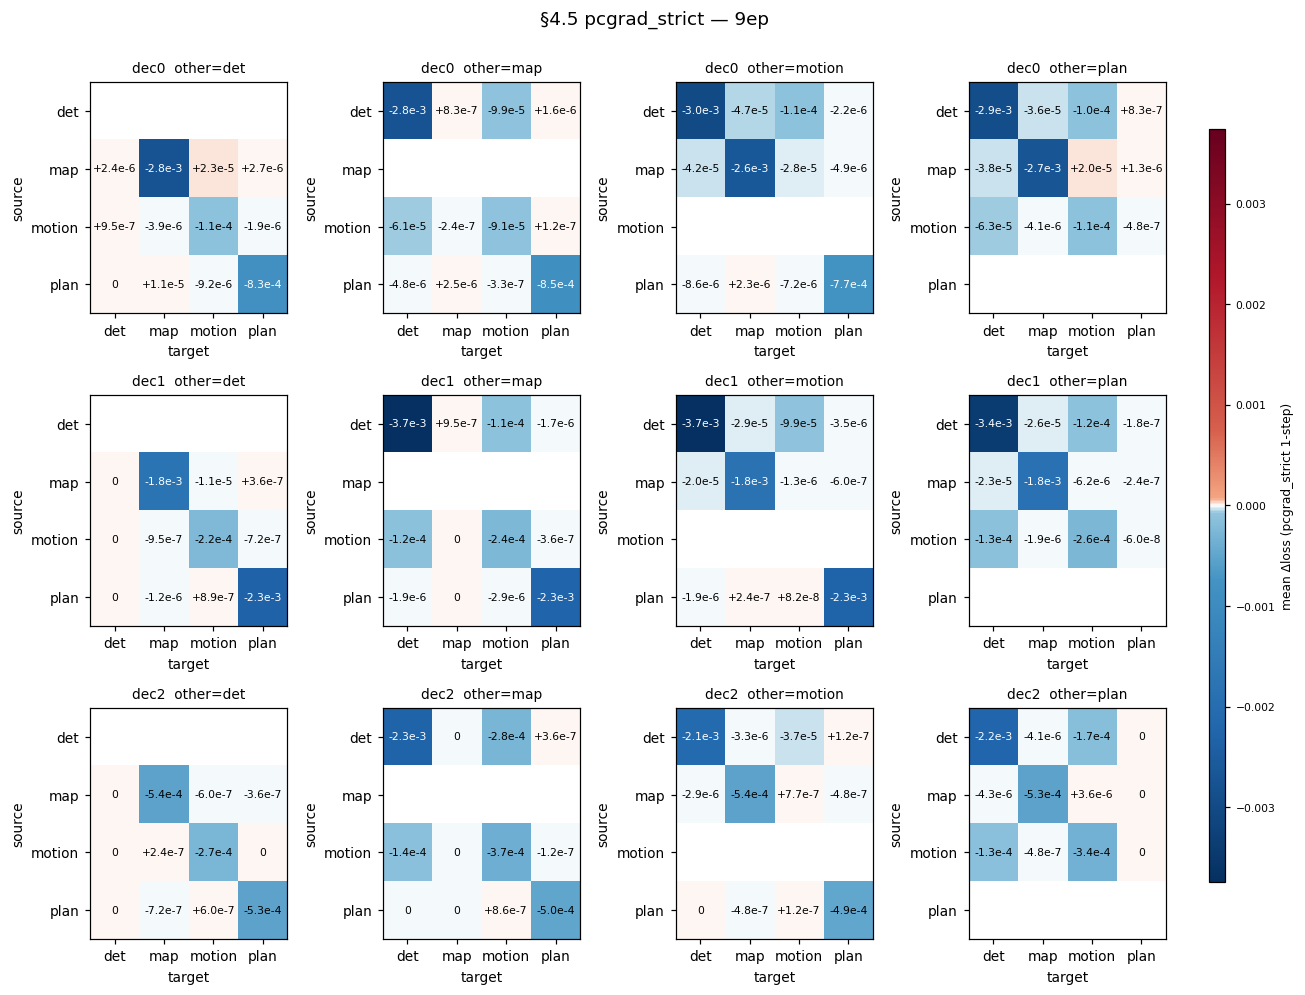

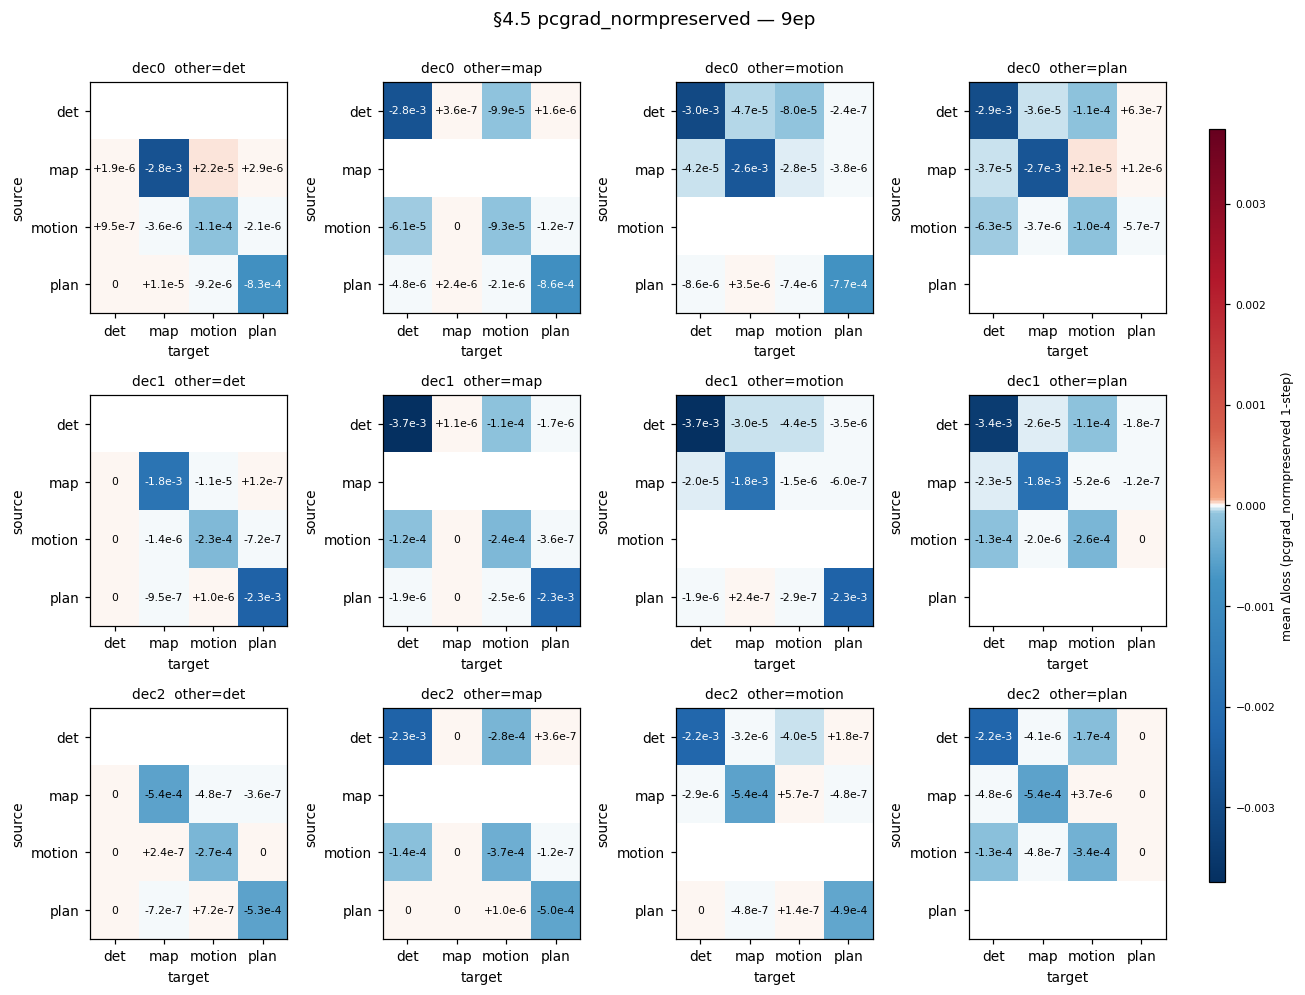

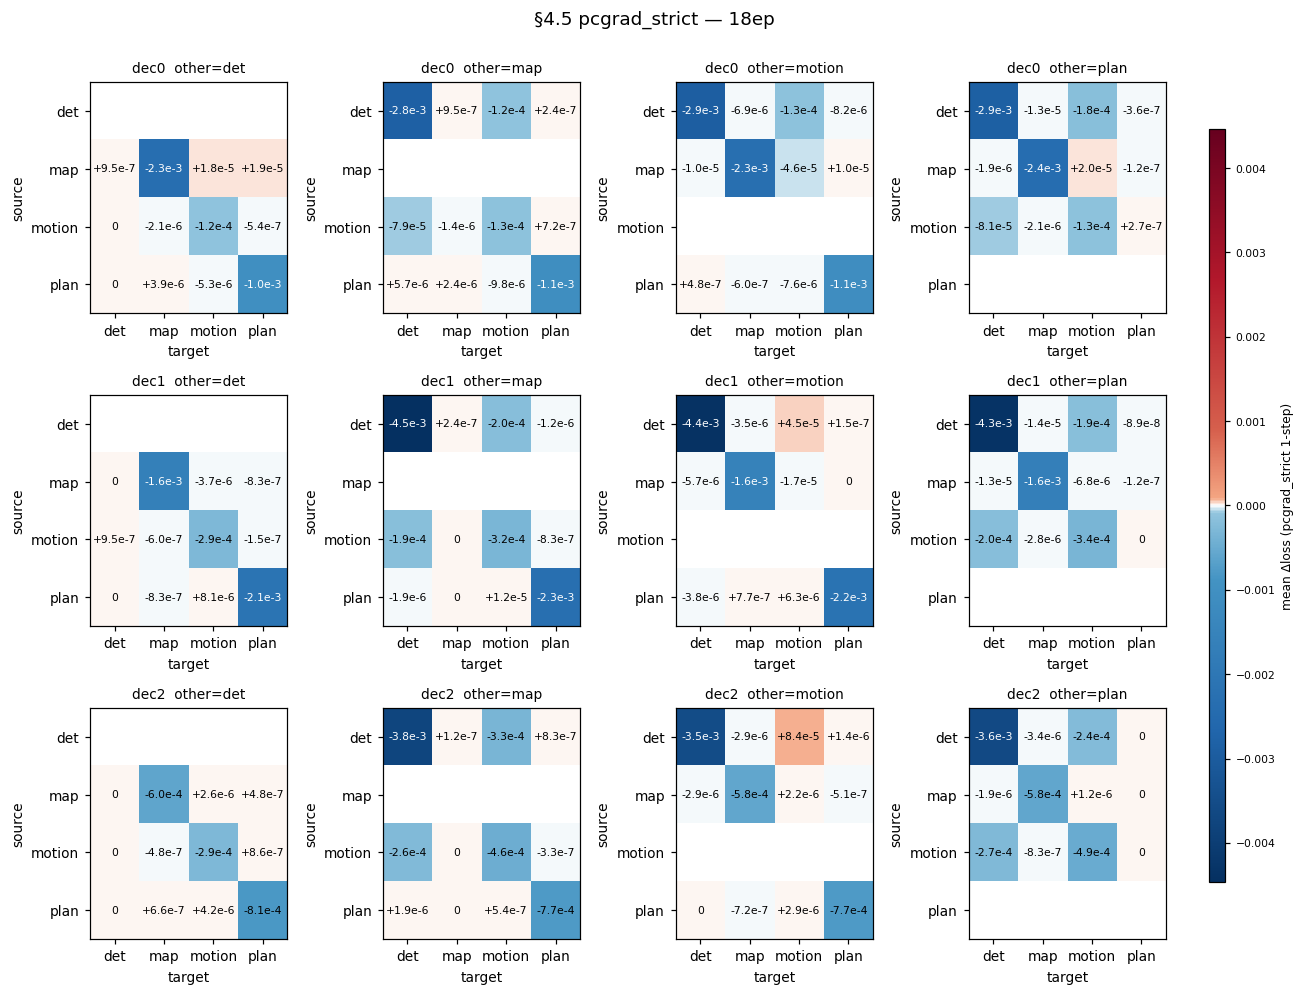

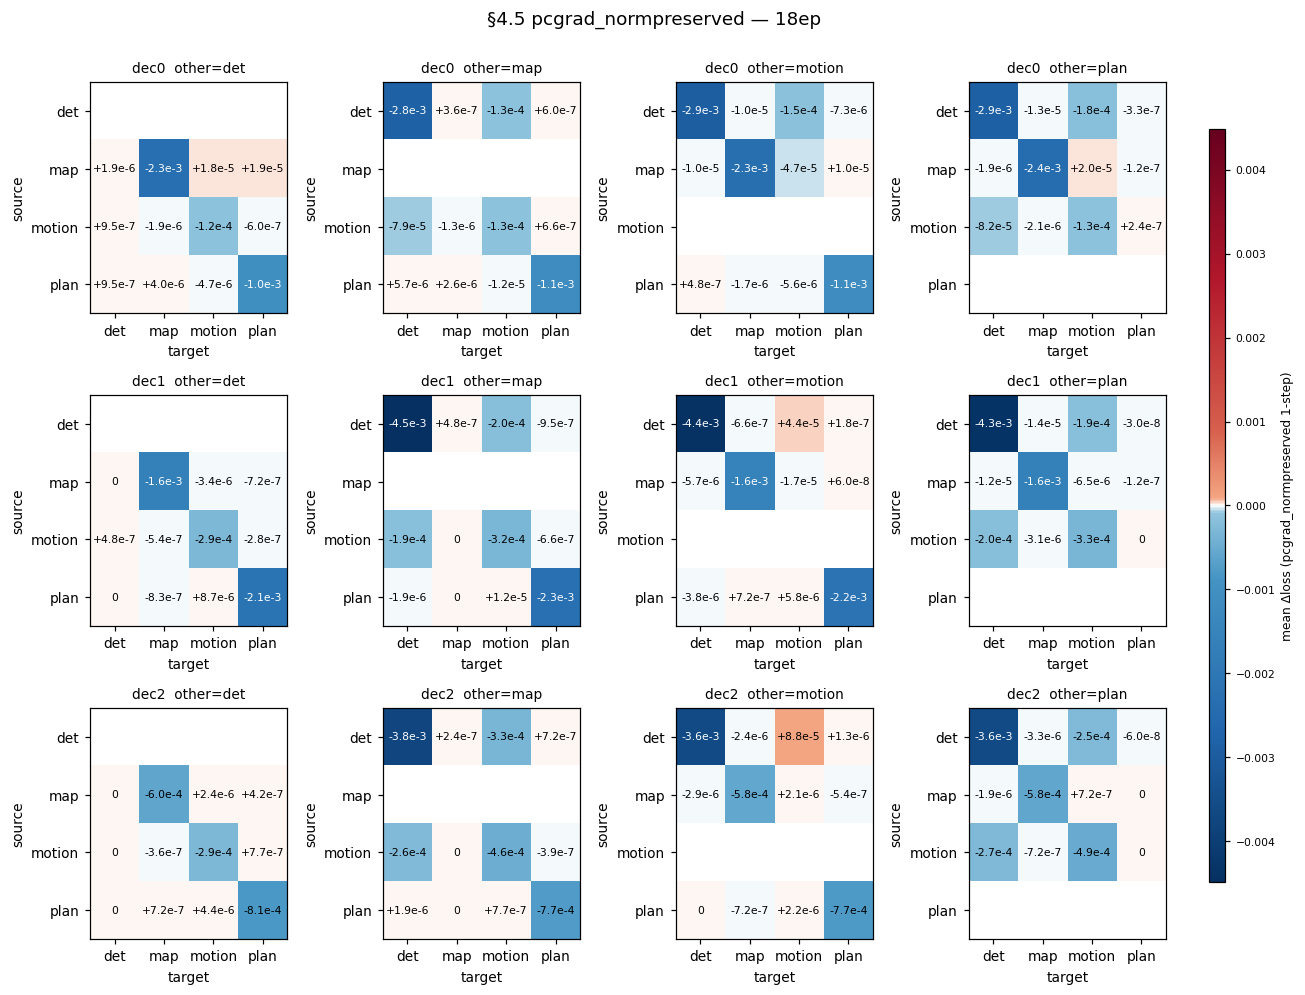

In [16]:
# 4.5 PCGrad variant heatmaps — layer × other_task grid per ckpt.
# 각 ckpt 한 줄, 한 줄 = (layer × other_task) grid.
PCGRAD_VARIANTS = ['pcgrad_strict', 'pcgrad_normpreserved']

def plot_pcgrad_cube(ckpt_tag, variant):
    sub = probe_per_batch[
        (probe_per_batch['checkpoint'] == ckpt_tag)
        & (probe_per_batch['variant'] == variant)
        & (probe_per_batch['steps'] == 1)
    ]
    if sub.empty or 'other_task' not in sub.columns:
        print(f'[{variant} @ {ckpt_tag}] empty')
        return
    others = [t for t in TASK_ORDER if t in sub['other_task'].unique()]
    layers = [L for L in TARGET_LAYERS if L in sub['layer'].unique()]
    if not others or not layers:
        print(f'[{variant} @ {ckpt_tag}] missing slices: others={others} layers={layers}')
        return
    nrows, ncols = len(layers), len(others)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.0 * ncols, 3.0 * nrows), squeeze=False)
    # global vmax for visual comparability
    vmax_g = 1e-12
    for L in layers:
        for o in others:
            m = probe_matrix(sub[sub['layer'] == L], variant=variant, other=o)
            if not m.empty:
                vmax_g = max(vmax_g, float(np.nanmax(np.abs(m.values))))
    im = None
    for i, L in enumerate(layers):
        for j, o in enumerate(others):
            ax = axes[i, j]
            m = probe_matrix(sub[sub['layer'] == L], variant=variant, other=o)
            ttl = f'{L.replace("_inter_gnn_0","")}  other={o}'
            im_new = draw_matrix(ax, m, ttl, vmax=vmax_g)
            if im_new is not None:
                im = im_new
    plt.suptitle(f'§4.5 {variant} — {ckpt_tag}', y=1.00)
    if im is not None:
        # Use a manual colorbar — _add_external_colorbar expects 1-row layout.
        fig.subplots_adjust(right=0.90)
        cax = fig.add_axes([0.92, 0.12, 0.012, 0.76])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label(f'mean Δloss ({variant} 1-step)', fontsize=8)
        cb.ax.tick_params(labelsize=7)
    plt.tight_layout(rect=[0, 0, 0.90, 1.0])
    plt.show()

for tag, _, _, _ in CKPTS:
    for v in PCGRAD_VARIANTS:
        plot_pcgrad_cube(tag, v)


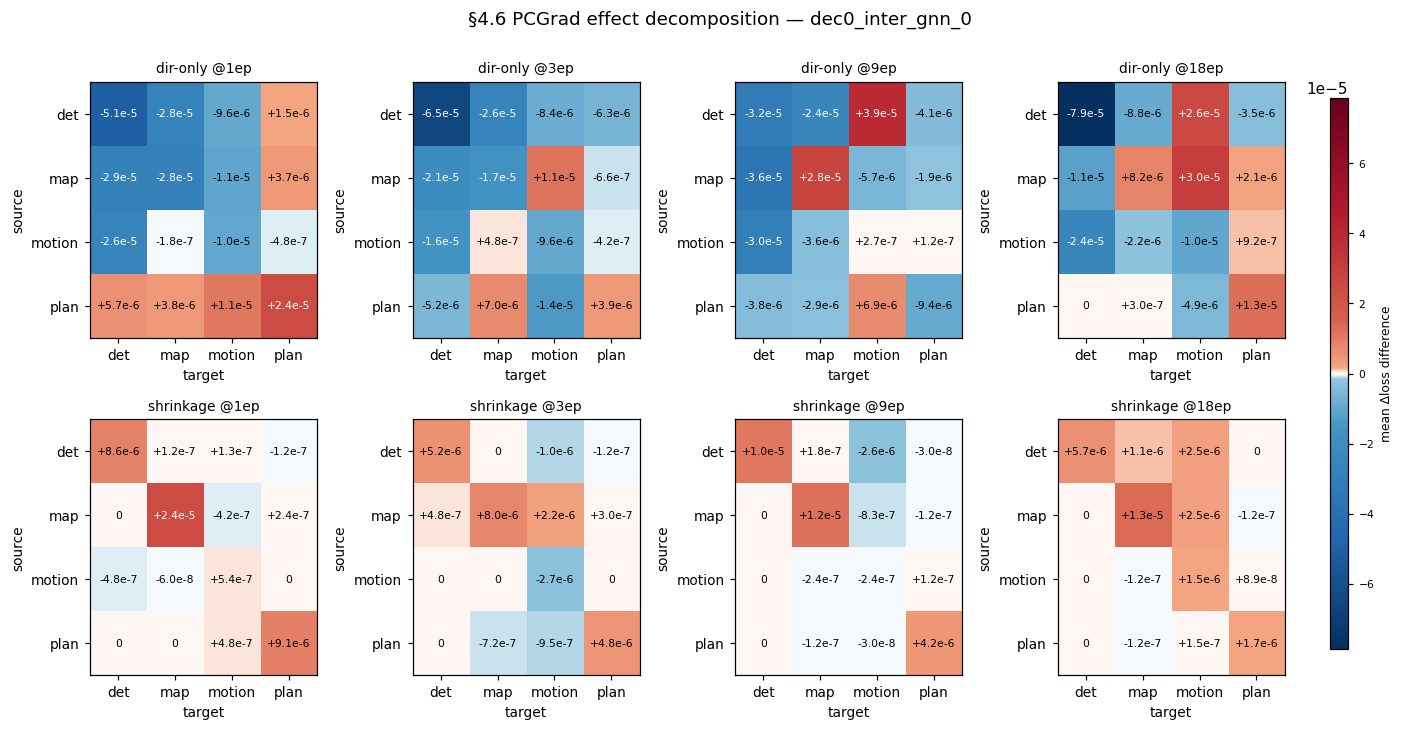

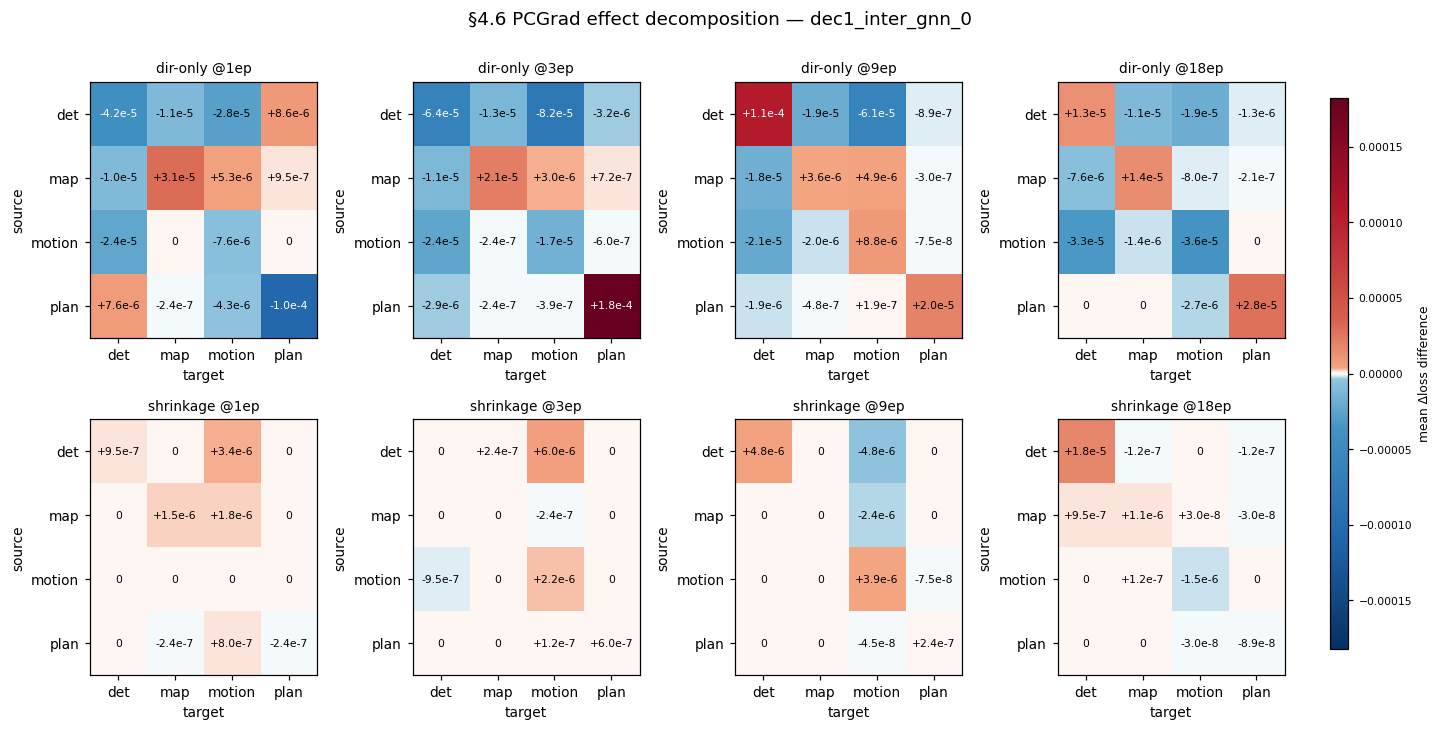

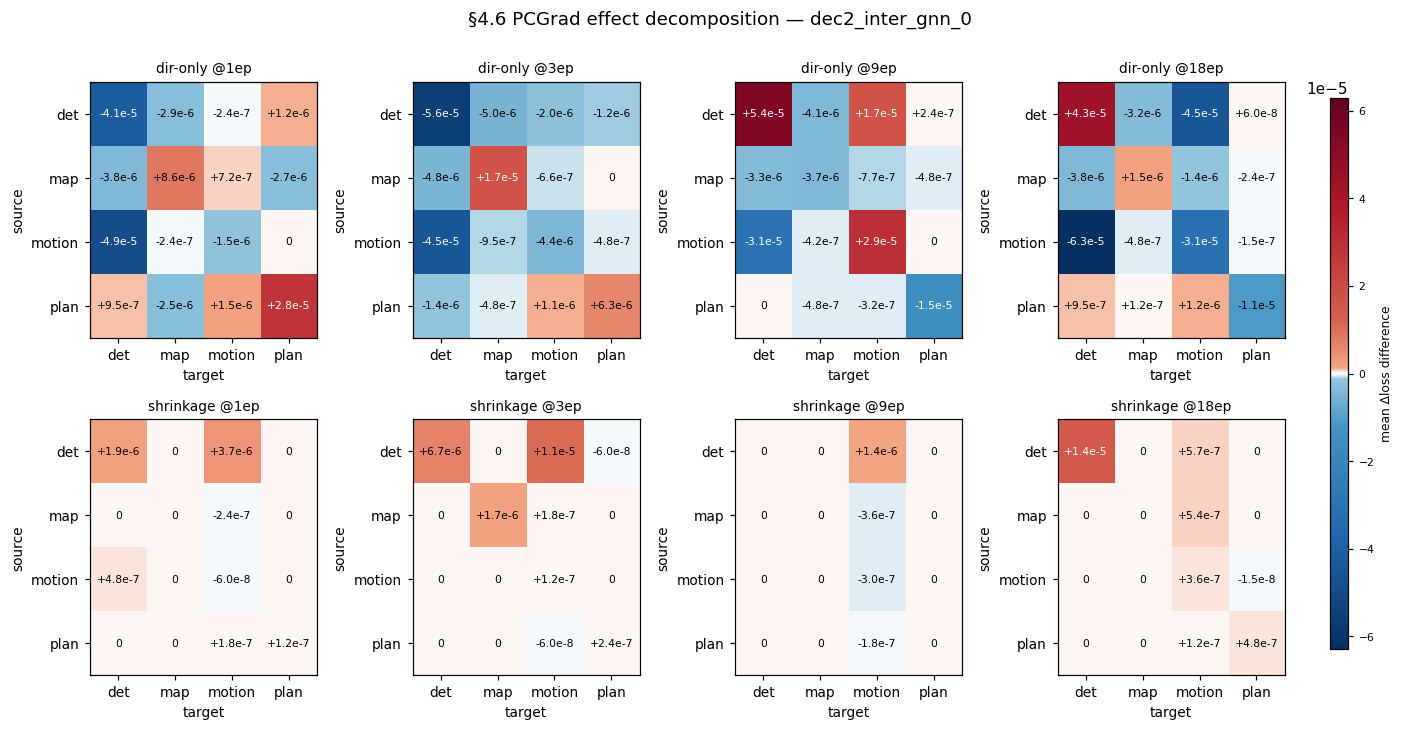

In [17]:
# 4.6 PCGrad effect decomposition — 평균 Δloss 차이로 direction-only vs shrinkage 분리.
#   direction_effect  ≈ raw - pcgrad_normpreserved   (방향 변화만)
#   shrinkage_effect  ≈ pcgrad_strict - pcgrad_normpreserved  (순수 magnitude shrinkage)
# 여기서는 (source, target) cell 평균만 본다 (other 축은 평균).

def mean_delta(variant, ckpt=None, layer=None):
    df = probe_per_batch[
        (probe_per_batch['variant'] == variant)
        & (probe_per_batch['steps'] == 1)
    ]
    if ckpt is not None:
        df = df[df['checkpoint'] == ckpt]
    if layer is not None:
        df = df[df['layer'] == layer]
    if df.empty:
        return pd.DataFrame()
    return (df.groupby(['source_task', 'target_task'])['delta']
              .median().unstack('target_task')
              .reindex(index=TASK_ORDER, columns=TASK_ORDER))

ckpts_here = [t for (t, _, _, _) in CKPTS]
for L in TARGET_LAYERS:
    if probe_per_batch[probe_per_batch['layer'] == L].empty:
        continue
    ncols = max(1, len(ckpts_here))
    fig, axes = plt.subplots(2, ncols, figsize=(3.3 * ncols, 6.6), squeeze=False)
    vmax_g = 1e-12
    # pre-scan vmax
    cells_data = []
    for c in ckpts_here:
        raw_m  = mean_delta('raw',                  ckpt=c, layer=L)
        nor_m  = mean_delta('pcgrad_normpreserved', ckpt=c, layer=L)
        str_m  = mean_delta('pcgrad_strict',        ckpt=c, layer=L)
        if raw_m.empty or nor_m.empty or str_m.empty:
            cells_data.append((c, None, None))
            continue
        dir_eff   = raw_m - nor_m
        shrink_eff = str_m - nor_m
        for m in (dir_eff, shrink_eff):
            vmax_g = max(vmax_g, float(np.nanmax(np.abs(m.values))))
        cells_data.append((c, dir_eff, shrink_eff))
    im = None
    for j, (c, dir_eff, shrink_eff) in enumerate(cells_data):
        ax0 = axes[0, j]; ax1 = axes[1, j]
        if dir_eff is None:
            ax0.set_title(f'{c} (empty)'); ax0.axis('off')
            ax1.set_title(f'{c} (empty)'); ax1.axis('off')
            continue
        im_new = draw_matrix(ax0, dir_eff,    f'dir-only @{c}',  vmax=vmax_g)
        im_new = draw_matrix(ax1, shrink_eff, f'shrinkage @{c}', vmax=vmax_g) or im_new
        if im_new is not None:
            im = im_new
    plt.suptitle(f'§4.6 PCGrad effect decomposition — {L}', y=1.00)
    if im is not None:
        fig.subplots_adjust(right=0.90)
        cax = fig.add_axes([0.92, 0.12, 0.012, 0.76])
        cb = fig.colorbar(im, cax=cax)
        cb.set_label('mean Δloss difference', fontsize=8)
        cb.ax.tick_params(labelsize=7)
    plt.tight_layout(rect=[0, 0, 0.90, 1.0])
    plt.show()


## 5. Planning importance — "planning 에 도움 주는 task 는 누구인가" (`M_PI`)

### 5.1 두 가지 척도
1. **alignment** (cheap proxy) — `cos(g_plan, g_aux)` 평균.
   - 양수면 두 gradient 가 같은 방향 → aux 가 plan 과 같은 곳을 "같이 밀고 있다".
   - 계산이 싸서 학습 안에서 실시간 게이팅에 쓸 수 있다.
2. **transfer** (causal) — `−E[Δ_{aux→plan}]` (probe 결과 부호 반전).
   - 양수면 aux step 이 plan loss 를 실제로 줄임 → "진짜로 plan 을 돕는다".
   - 비싸지만 인과적 신호.

### 5.2 Scene-dependence (winner 분포)
- batch(scene) 마다 alignment / transfer 의 1위 task 를 뽑은 분포.
- **normalized entropy ≈ 1.0** ⇒ scene 마다 winner 가 바뀜 → **per-scene weighting 의 근거**.
- entropy ≪ 1.0 ⇒ 특정 task 가 거의 항상 winner → 정적 weighting 으로 충분.

### 5.3 Agreement (proxy ↔ causal)
- `spearman`, `per_batch_winner_agreement`, `sign_agreement` 가 모두 양수면 cheap cosine proxy 가 causal probe 와 같은 순위를 줌 → **online 에 alignment 만 써도 됨**.
- 어긋나면 cosine 만 보고 가중치를 켜면 잘못된 task 를 도와줄 위험.

### 5.4 Layer sensitivity
- `planning_layer_sensitivity.csv` — layer 별 `‖∂L_plan / ∂θ‖` 평균.
- decoder 깊이별로 planning gradient 의 강도가 어떻게 분포하는가. surgery/weighting hook 후보 layer 선정에 사용.

,aux_task,n_align,n_transfer,align_score,align_pos_rate,align_ci_lo,align_ci_hi,transfer_gain,helpful_rate,transfer_ci_lo,transfer_ci_hi,motion_det_collinearity,flag_det_collinear,checkpoint,iter,epoch,__file
0,det,3000,3000,-0.001337,0.474667,-0.002933,0.000314,-0.000012,0.462333,-0.000022,-0.000005,NaN,False,1ep,1758,1.0,importance_summary.csv
1,map,3000,3000,-0.002049,0.493667,-0.004257,0.000270,-0.000011,0.513667,-0.000020,-0.000001,NaN,False,1ep,1758,1.0,importance_summary.csv
2,motion,3000,3000,0.000580,0.496667,-0.001406,0.002593,0.000001,0.493000,-0.000001,0.000003,0.210074,False,1ep,1758,1.0,importance_summary.csv
3,det,3000,3000,0.000221,0.502667,-0.001210,0.001646,0.000010,0.525000,0.000002,0.000019,NaN,False,3ep,5274,3.0,importance_summary.csv
4,map,3000,3000,0.001974,0.516000,0.000138,0.003935,-0.000001,0.492333,-0.000009,0.000008,NaN,False,3ep,5274,3.0,importance_summary.csv
5,motion,3000,3000,0.000604,0.509000,-0.001611,0.002738,0.000003,0.516000,0.000000,0.000006,0.189085,False,3ep,5274,3.0,importance_summary.csv
6,det,3000,3000,-0.000224,0.490333,-0.001450,0.000954,0.000003,0.511333,-0.000003,0.000008,NaN,False,9ep,15822,9.0,importance_summary.csv
7,map,3000,3000,0.001737,0.511333,0.000082,0.003431,-0.000006,0.513333,-0.000013,0.000000,NaN,False,9ep,15822,9.0,importance_summary.csv
8,motion,3000,3000,0.001585,0.512000,-0.000039,0.003256,-0.000000,0.502333,-0.000002,0.000002,0.167520,False,9ep,15822,9.0,importance_summary.csv
9,det,3000,3000,0.002198,0.530667,0.000831,0.003508,0.000003,0.512667,-0.000003,0.000009,NaN,False,18ep,31644,18.0,importance_summary.csv


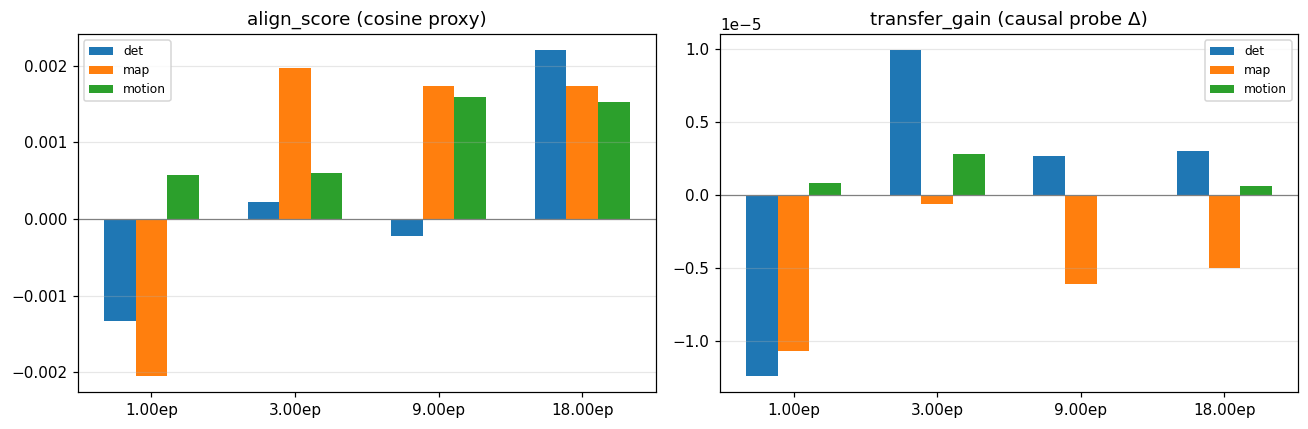

In [18]:
# 5.1 Importance summary — align_score & transfer_gain with 95% CI (aux task별 × ckpt별)
if pi_summary.empty:
    print('[planning_importance] empty')
else:
    display(pi_summary.sort_values(['epoch', 'aux_task']).round(6))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    aux_tasks = ['det', 'map', 'motion']
    width = 0.22
    epochs_sorted = sorted(pi_summary['epoch'].unique())
    for ax, (col, lo, hi, ttl) in zip(axes, [
        ('align_score',   'align_ci_lo',    'align_ci_hi',    'align_score (cosine proxy)'),
        ('transfer_gain', 'transfer_ci_lo', 'transfer_ci_hi', 'transfer_gain (causal probe Δ)')]):
        for j, t in enumerate(aux_tasks):
            sub = pi_summary[pi_summary['aux_task'] == t].sort_values('epoch')
            xs = np.arange(len(sub)) + (j - 1) * width
            ax.bar(xs, sub[col], width=width, label=t)
        ax.axhline(0, color='gray', lw=0.8)
        ax.set_xticks(np.arange(len(epochs_sorted)))
        ax.set_xticklabels([f'{e:.2f}ep' for e in epochs_sorted])
        ax.set_title(ttl); ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

=== align_score per (layer, aux_task) — epoch-pooled ===


,layer,aux_task,align_score,std,count,ci
0,dec0_inter_gnn_0,det,0.001107,0.002614,4,0.002561
1,dec0_inter_gnn_0,map,-0.000185,0.005509,4,0.005398
2,dec0_inter_gnn_0,motion,0.002935,0.001670,4,0.001637
3,dec1_inter_gnn_0,det,-0.000529,0.001549,4,0.001518
4,dec1_inter_gnn_0,map,0.000763,0.001005,4,0.000985
5,dec1_inter_gnn_0,motion,0.000552,0.000199,4,0.000195
6,dec2_inter_gnn_0,det,0.000067,0.000632,4,0.000620
7,dec2_inter_gnn_0,map,0.001964,0.000579,4,0.000567
8,dec2_inter_gnn_0,motion,-0.000269,0.000206,4,0.000202



=== transfer_gain per (layer, aux_task) — epoch-pooled ===


,layer,aux_task,transfer_gain,std,count,ci
0,dec0_inter_gnn_0,det,0.000002,0.000344,4000,0.000011
1,dec0_inter_gnn_0,map,-0.000014,0.000367,4000,0.000011
2,dec0_inter_gnn_0,motion,0.000002,0.000093,4000,0.000003
3,dec1_inter_gnn_0,det,-0.000001,0.000101,4000,0.000003
4,dec1_inter_gnn_0,map,-0.000005,0.000090,4000,0.000003
5,dec1_inter_gnn_0,motion,0.000000,0.000045,4000,0.000001
6,dec2_inter_gnn_0,det,0.000001,0.000052,4000,0.000002
7,dec2_inter_gnn_0,map,0.000001,0.000029,4000,0.000001
8,dec2_inter_gnn_0,motion,0.000001,0.000042,4000,0.000001


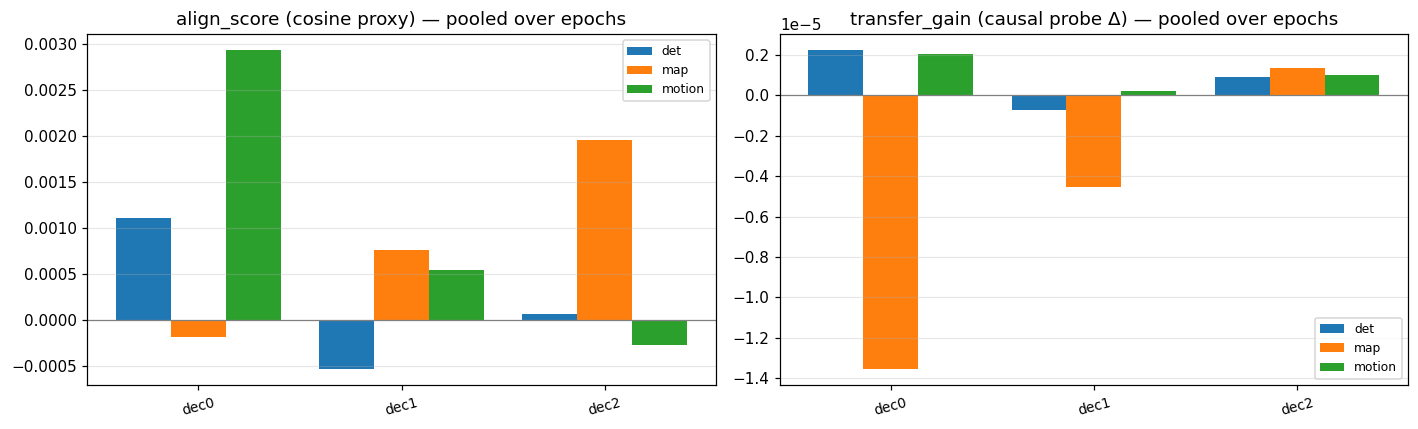

In [19]:
# 5.1c Layer-resolved importance — §5.1 과 같은 (bar + 95% CI) 스타일을 layer 축으로
# §5.1 = epoch × aux (layer-averaged) / §5.1b = epoch × layer × aux (grid) / §5.1c = layer × aux (epoch-pooled)
# 학습 전체를 평균해서 "어느 inter-GNN depth 가 가장 강한 plan-aux signal 을 가지는가" 한 장 요약.

aux_tasks = ['det', 'map', 'motion']

# (a) align: plan-aux pair cosine, epoch 축 pool
if real_layer.empty:
    align_lyr_pooled = pd.DataFrame()
else:
    _df = real_layer[(real_layer['task_a'] == 'plan') | (real_layer['task_b'] == 'plan')].copy()
    _df['aux_task'] = np.where(_df['task_a'] == 'plan', _df['task_b'], _df['task_a'])
    g = (_df.groupby(['group', 'aux_task'])['mean_cos']
            .agg(['mean', 'std', 'count']).reset_index())
    g['ci'] = 1.96 * g['std'] / np.sqrt(g['count'].clip(lower=1))
    align_lyr_pooled = g.rename(columns={'group': 'layer', 'mean': 'align_score'})

# (b) transfer: -Δloss (source=aux, target=plan), epoch×batch 축 pool
if probe_per_batch.empty:
    transfer_lyr_pooled = pd.DataFrame()
else:
    pr = probe_per_batch[
        (probe_per_batch['variant'] == DEFAULT_PROBE_VARIANT)
        & (probe_per_batch['steps'] == 1)
        & (probe_per_batch['target_task'] == 'plan')
        & (probe_per_batch['source_task'] != 'plan')
    ].copy()
    pr['gain'] = -pr['delta']
    g = (pr.groupby(['layer', 'source_task'])['gain']
           .agg(['mean', 'std', 'count']).reset_index())
    g['ci'] = 1.96 * g['std'] / np.sqrt(g['count'].clip(lower=1))
    transfer_lyr_pooled = g.rename(columns={'source_task': 'aux_task', 'mean': 'transfer_gain'})

if align_lyr_pooled.empty and transfer_lyr_pooled.empty:
    print('[planning_importance layer-pooled] empty')
else:
    print('=== align_score per (layer, aux_task) — epoch-pooled ===')
    if not align_lyr_pooled.empty:
        display(align_lyr_pooled.sort_values(['layer', 'aux_task']).round(6))
    print('\n=== transfer_gain per (layer, aux_task) — epoch-pooled ===')
    if not transfer_lyr_pooled.empty:
        display(transfer_lyr_pooled.sort_values(['layer', 'aux_task']).round(6))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    width = 0.27
    layers_for_x = TARGET_LAYERS
    xticks = [L.replace('_inter_gnn_0', '') for L in layers_for_x]
    for ax, (df_lyr, ycol, ttl) in zip(axes, [
        (align_lyr_pooled,    'align_score',   'align_score (cosine proxy) — pooled over epochs'),
        (transfer_lyr_pooled, 'transfer_gain', 'transfer_gain (causal probe Δ) — pooled over epochs')]):
        if df_lyr.empty:
            ax.set_title(ttl + ' (empty)'); ax.axis('off'); continue
        for j, t in enumerate(aux_tasks):
            sub = (df_lyr[df_lyr['aux_task'] == t]
                   .set_index('layer').reindex(layers_for_x).reset_index())
            xs = np.arange(len(layers_for_x)) + (j - 1) * width
            ax.bar(xs, sub[ycol], width=width, label=t)
        ax.axhline(0, color='gray', lw=0.8)
        ax.set_xticks(np.arange(len(layers_for_x)))
        ax.set_xticklabels(xticks, fontsize=9, rotation=15)
        ax.set_title(ttl); ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

=== align_score per (aux_task, layer, epoch) ===


,epoch,iter,checkpoint,aux_task,layer,align_score
6,1.0,1758,1ep,det,dec0_inter_gnn_0,-0.001272
12,1.0,1758,1ep,map,dec0_inter_gnn_0,-0.008401
15,1.0,1758,1ep,motion,dec0_inter_gnn_0,0.001522
7,1.0,1758,1ep,det,dec1_inter_gnn_0,-0.002752
13,1.0,1758,1ep,map,dec1_inter_gnn_0,-0.000266
16,1.0,1758,1ep,motion,dec1_inter_gnn_0,0.000298
8,1.0,1758,1ep,det,dec2_inter_gnn_0,0.000014
14,1.0,1758,1ep,map,dec2_inter_gnn_0,0.002521
17,1.0,1758,1ep,motion,dec2_inter_gnn_0,-0.000081
24,3.0,5274,3ep,det,dec0_inter_gnn_0,0.000864



=== transfer_gain per (aux_task, layer, epoch) ===


,epoch,iter,checkpoint,aux_task,layer,transfer_gain
0,1.0,1758,1ep,det,dec0_inter_gnn_0,-0.000002
3,1.0,1758,1ep,map,dec0_inter_gnn_0,-0.000002
6,1.0,1758,1ep,motion,dec0_inter_gnn_0,0.000000
1,1.0,1758,1ep,det,dec1_inter_gnn_0,-0.000009
4,1.0,1758,1ep,map,dec1_inter_gnn_0,-0.000001
7,1.0,1758,1ep,motion,dec1_inter_gnn_0,-0.000000
2,1.0,1758,1ep,det,dec2_inter_gnn_0,-0.000001
5,1.0,1758,1ep,map,dec2_inter_gnn_0,0.000003
8,1.0,1758,1ep,motion,dec2_inter_gnn_0,-0.000000
9,3.0,5274,3ep,det,dec0_inter_gnn_0,0.000008


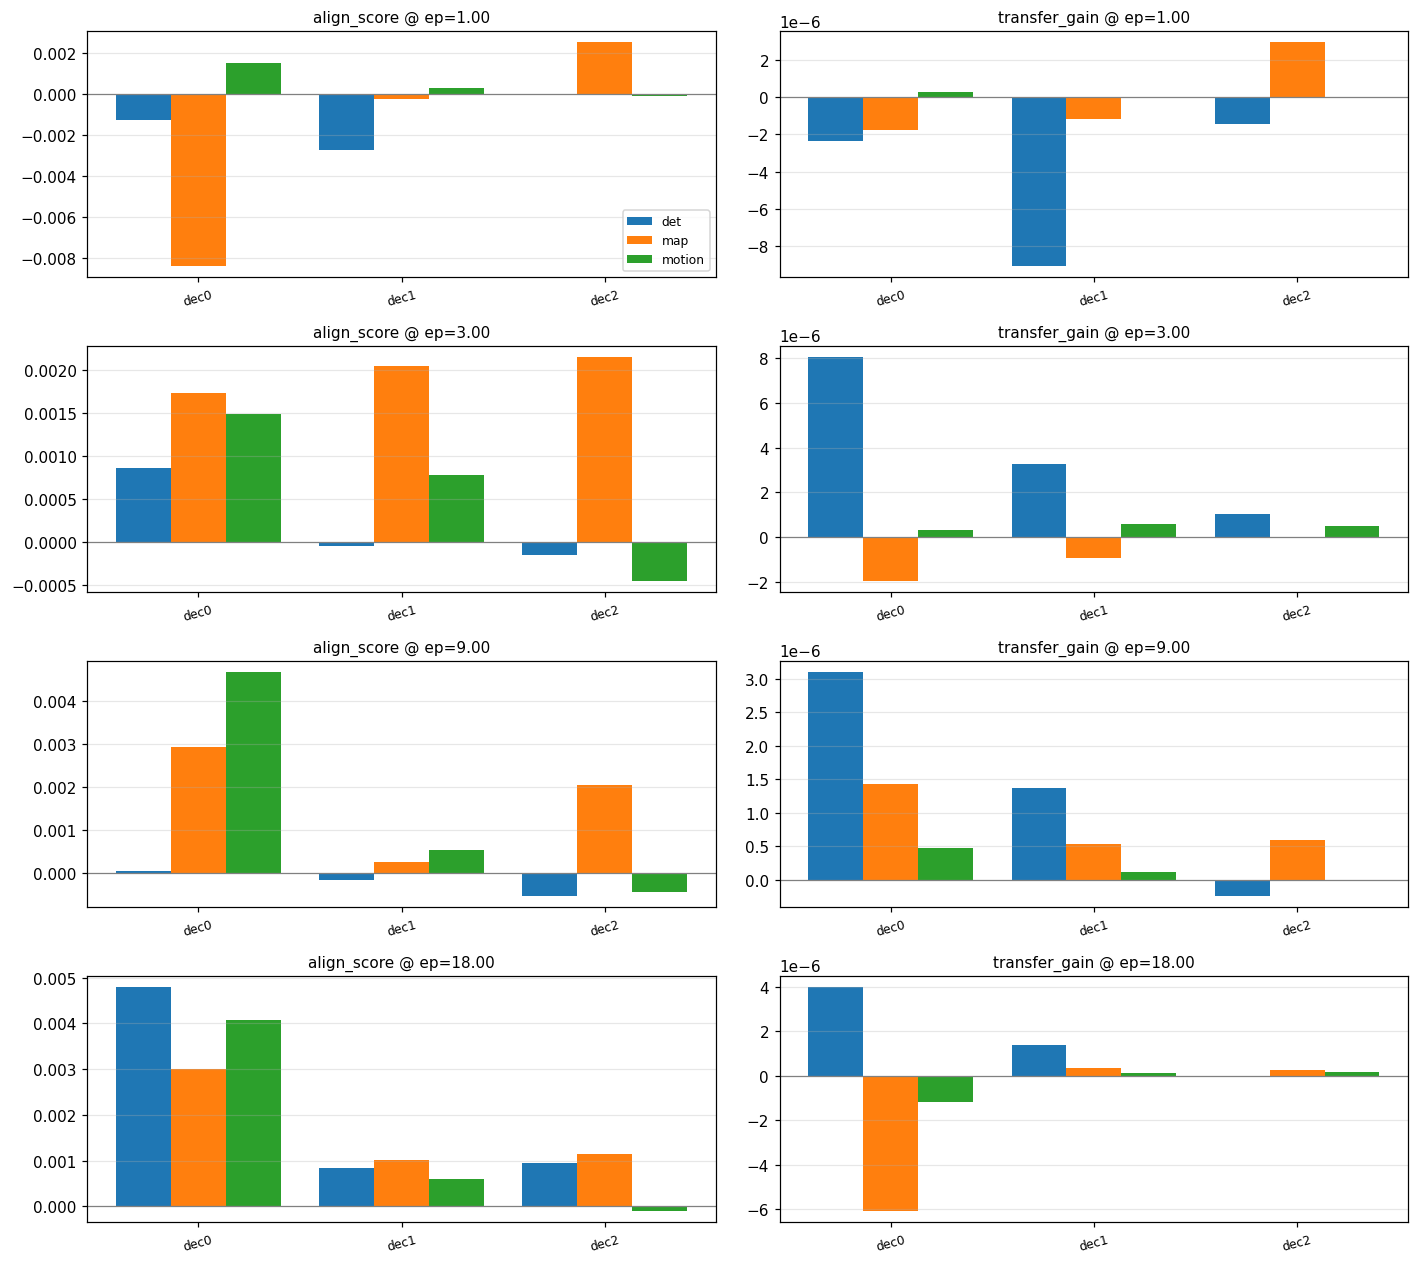

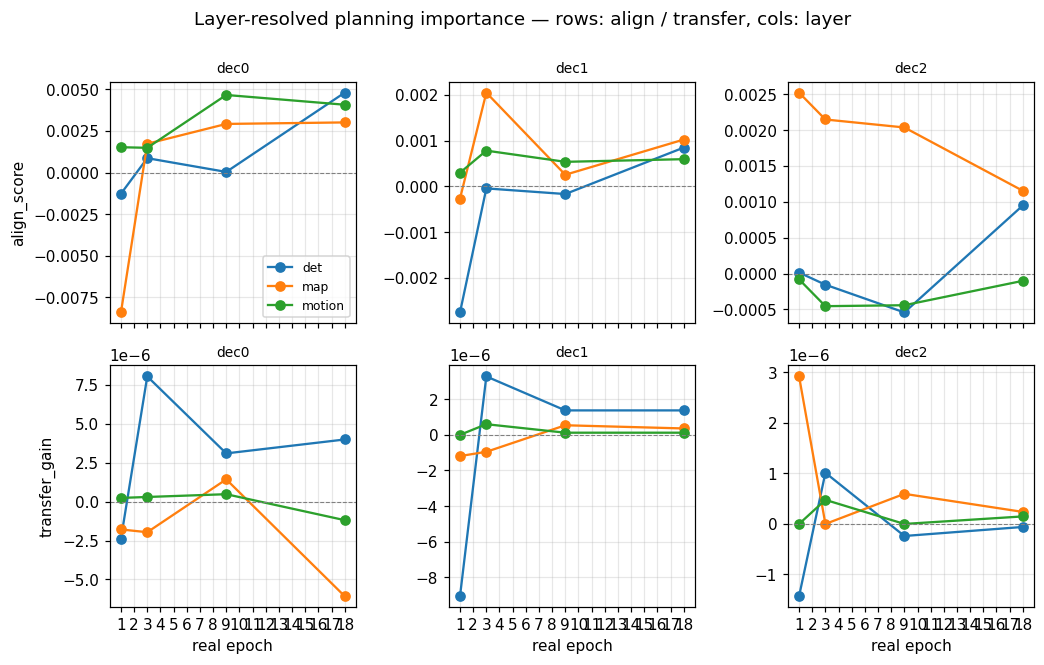

In [20]:
# 5.1b Layer-resolved planning importance — align & transfer per inter-GNN layer
#
# §5.1 은 layer-averaged. 여기서는 같은 두 지표를 inter-GNN layer 6개 × epoch
# grid 로 풀어본다.  어느 depth 에서 plan-aux signal 이 강하게 살아남는지, 또는
# 어느 layer 가 wash-out 에 기여하는지를 본다.
#
# 데이터 출처 (재계산):
#   align_score(per layer) = conflict_layer.mean_cos  where (task=plan) ∈ pair
#   transfer_gain(per layer) = -mean(probe_per_batch.delta)  where source=aux, target=plan

# (a) align: plan-aux pair 의 cosine
if real_layer.empty:
    align_lyr = pd.DataFrame()
else:
    _df = real_layer.copy()
    _df = _df[(_df['task_a'] == 'plan') | (_df['task_b'] == 'plan')].copy()
    _df['aux_task'] = np.where(_df['task_a'] == 'plan', _df['task_b'], _df['task_a'])
    align_lyr = (_df.rename(columns={'group': 'layer', 'mean_cos': 'align_score'})
                    [['epoch', 'iter', 'checkpoint', 'aux_task', 'layer', 'align_score']])

# (b) transfer: probe 의 (source=aux, target=plan) 평균 delta 의 부호 반전
if probe_per_batch.empty:
    transfer_lyr = pd.DataFrame()
else:
    _pr = probe_per_batch[
        (probe_per_batch['variant'] == DEFAULT_PROBE_VARIANT)
        & (probe_per_batch['steps'] == 1)
        & (probe_per_batch['target_task'] == 'plan')
        & (probe_per_batch['source_task'] != 'plan')
    ]
    _g = (_pr.groupby(['epoch', 'iter', 'checkpoint', 'source_task', 'layer'])['delta']
              .median().reset_index())
    _g['transfer_gain'] = -_g['delta']
    transfer_lyr = (_g.rename(columns={'source_task': 'aux_task'})
                      [['epoch', 'iter', 'checkpoint', 'aux_task', 'layer', 'transfer_gain']])

print('=== align_score per (aux_task, layer, epoch) ===')
if not align_lyr.empty:
    display(align_lyr.sort_values(['epoch', 'layer', 'aux_task']).round(6))
print('\n=== transfer_gain per (aux_task, layer, epoch) ===')
if not transfer_lyr.empty:
    display(transfer_lyr.sort_values(['epoch', 'layer', 'aux_task']).round(6))

# (c) bar facet: 각 epoch 마다 (layer × aux) → align & transfer 두 metric
aux_tasks = ['det', 'map', 'motion']
epochs_sorted = sorted(set(align_lyr['epoch'].unique() if not align_lyr.empty else []) |
                      set(transfer_lyr['epoch'].unique() if not transfer_lyr.empty else []))
if epochs_sorted:
    nrows = len(epochs_sorted)
    fig, axes = plt.subplots(nrows, 2, figsize=(13, 2.9 * nrows), squeeze=False)
    for i, ep in enumerate(epochs_sorted):
        for j, (df_lyr, ycol, ttl) in enumerate([
            (align_lyr,    'align_score',   f'align_score @ ep={ep:.2f}'),
            (transfer_lyr, 'transfer_gain', f'transfer_gain @ ep={ep:.2f}'),
        ]):
            ax = axes[i, j]
            sub = df_lyr[df_lyr['epoch'] == ep] if not df_lyr.empty else pd.DataFrame()
            if sub.empty:
                ax.set_title(ttl + ' (empty)', fontsize=9); ax.axis('off'); continue
            width = 0.27
            for k, t in enumerate(aux_tasks):
                tsub = (sub[sub['aux_task'] == t]
                        .set_index('layer').reindex(TARGET_LAYERS).reset_index())
                xs = np.arange(len(TARGET_LAYERS)) + (k - 1) * width
                ax.bar(xs, tsub[ycol], width=width, label=t)
            ax.axhline(0, color='gray', lw=0.8)
            ax.set_xticks(np.arange(len(TARGET_LAYERS)))
            ax.set_xticklabels([L.replace('_inter_gnn_0', '') for L in TARGET_LAYERS],
                               fontsize=8, rotation=15)
            ax.set_title(ttl, fontsize=10); ax.grid(axis='y', alpha=0.3)
            if i == 0 and j == 0:
                ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

# (d) line facet: 각 layer 마다 epoch 추세 (aux 별 색). 1단위 epoch tick.
if not (align_lyr.empty and transfer_lyr.empty):
    fig, axes = plt.subplots(2, len(TARGET_LAYERS), figsize=(3.2 * len(TARGET_LAYERS), 6),
                             squeeze=False, sharex=True)
    for j, L in enumerate(TARGET_LAYERS):
        for i, (df_lyr, ycol, ylabel) in enumerate([
            (align_lyr,    'align_score',   'align_score'),
            (transfer_lyr, 'transfer_gain', 'transfer_gain'),
        ]):
            ax = axes[i, j]
            if df_lyr.empty:
                ax.axis('off'); continue
            for t in aux_tasks:
                sub = (df_lyr[(df_lyr['layer'] == L) & (df_lyr['aux_task'] == t)]
                       .sort_values('epoch'))
                if sub.empty:
                    continue
                ax.plot(sub['epoch'], sub[ycol], marker='o', label=t)
            ax.axhline(0, color='gray', ls='--', lw=0.7)
            ax.set_title(L.replace('_inter_gnn_0', ''), fontsize=9)
            if j == 0:
                ax.set_ylabel(ylabel)
            if i == 1:
                ax.set_xlabel('real epoch')
            ax.grid(alpha=0.3)
            set_epoch_xaxis(ax, step=1)
            if i == 0 and j == 0:
                ax.legend(fontsize=8)
    plt.suptitle('Layer-resolved planning importance — rows: align / transfer, cols: layer', y=1.00)
    plt.tight_layout(); plt.show()

,aux_task,win_count,win_frac,metric,normalized_entropy,checkpoint,iter,epoch,__file
0,det,285,0.285,alignment,0.9951,1ep,1758,1.0,scene_winner_distribution.csv
1,map,358,0.358,alignment,0.9951,1ep,1758,1.0,scene_winner_distribution.csv
2,motion,357,0.357,alignment,0.9951,1ep,1758,1.0,scene_winner_distribution.csv
3,det,330,0.330,transfer,0.9952,1ep,1758,1.0,scene_winner_distribution.csv
4,map,377,0.377,transfer,0.9952,1ep,1758,1.0,scene_winner_distribution.csv
5,motion,293,0.293,transfer,0.9952,1ep,1758,1.0,scene_winner_distribution.csv
6,det,284,0.284,alignment,0.9944,3ep,5274,3.0,scene_winner_distribution.csv
7,map,372,0.372,alignment,0.9944,3ep,5274,3.0,scene_winner_distribution.csv
8,motion,344,0.344,alignment,0.9944,3ep,5274,3.0,scene_winner_distribution.csv
9,det,333,0.333,transfer,0.9851,3ep,5274,3.0,scene_winner_distribution.csv


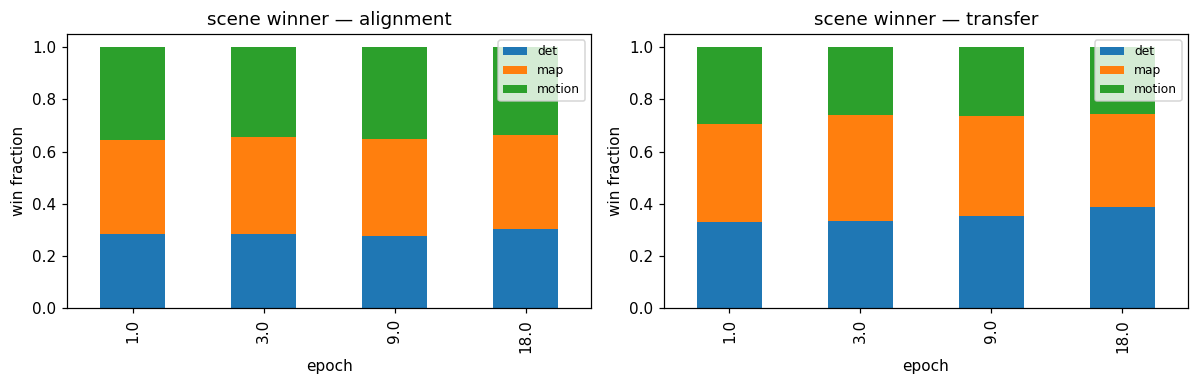

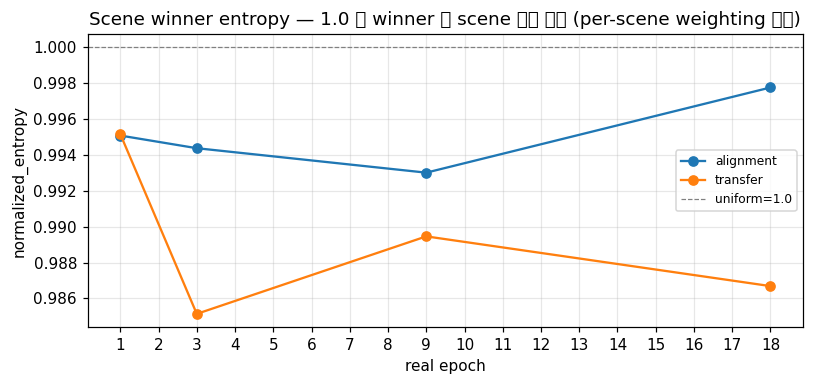

In [21]:
# 5.2 Scene winner distribution — task별 우승 비율 (win_frac) + normalized entropy
if pi_winner_dist.empty:
    print('[scene_winner_distribution] empty')
else:
    display(pi_winner_dist.sort_values(['epoch', 'metric', 'aux_task']).round(4))
    metrics = sorted(pi_winner_dist['metric'].unique())
    epochs = sorted(pi_winner_dist['epoch'].unique())
    fig, axes = plt.subplots(1, len(metrics), figsize=(5.5 * len(metrics), 3.6), squeeze=False)
    for ax, m in zip(axes[0], metrics):
        sub = pi_winner_dist[pi_winner_dist['metric'] == m]
        pivot = (sub.pivot_table(index='epoch', columns='aux_task',
                                 values='win_frac', aggfunc='mean')
                    .reindex(epochs))
        pivot.plot(kind='bar', stacked=True, ax=ax)
        ax.set_title(f'scene winner — {m}')
        ax.set_ylabel('win fraction'); ax.set_xlabel('epoch')
        ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

    ent = (pi_winner_dist.drop_duplicates(['epoch', 'metric'])[
               ['epoch', 'metric', 'normalized_entropy']]
           .sort_values(['metric', 'epoch']))
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    for m, g in ent.groupby('metric'):
        ax.plot(g['epoch'], g['normalized_entropy'], marker='o', label=m)
    ax.axhline(1.0, color='gray', ls='--', lw=0.8, label='uniform=1.0')
    ax.set_xlabel('real epoch'); ax.set_ylabel('normalized_entropy')
    ax.set_title('Scene winner entropy — 1.0 면 winner 가 scene 마다 바뀜 (per-scene weighting 근거)')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    set_epoch_xaxis(ax, step=1)
    plt.tight_layout(); plt.show()

,checkpoint,iter,epoch,spearman,per_batch_winner_agreement,sign_agreement,n_joined
0,1ep,1758,1.0,0.1965,0.389,0.5627,3000
1,3ep,5274,3.0,0.1558,0.402,0.5643,3000
2,9ep,15822,9.0,0.1463,0.385,0.5597,3000
3,18ep,31644,18.0,0.1070,0.351,0.5473,3000


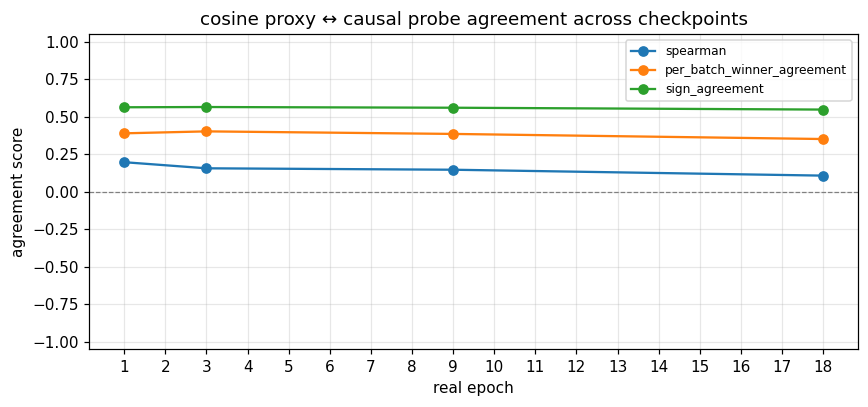

In [22]:
# 5.3 Agreement — cheap cosine proxy vs causal probe (per checkpoint)
# spearman / per_batch_winner_agreement / sign_agreement 가 모두 양수면 online 에 cosine 만 써도 OK
if pi_agreement.empty:
    print('[alignment_transfer_agreement] empty')
else:
    agg = pi_agreement.sort_values('epoch').reset_index(drop=True)
    show_cols = [c for c in ['checkpoint', 'iter', 'epoch', 'spearman',
                              'per_batch_winner_agreement', 'sign_agreement', 'n_joined']
                 if c in agg.columns]
    display(agg[show_cols].round(4))
    fig, ax = plt.subplots(figsize=(8, 3.8))
    for col in ['spearman', 'per_batch_winner_agreement', 'sign_agreement']:
        if col in agg.columns:
            ax.plot(agg['epoch'], agg[col], marker='o', label=col)
    ax.axhline(0.0, color='gray', ls='--', lw=0.8)
    ax.set_xlabel('real epoch'); ax.set_ylabel('agreement score')
    ax.set_title('cosine proxy ↔ causal probe agreement across checkpoints')
    ax.set_ylim(-1.05, 1.05); ax.grid(alpha=0.3); ax.legend(fontsize=8)
    set_epoch_xaxis(ax, step=1)
    plt.tight_layout(); plt.show()

,checkpoint,iter,epoch,sign_agreement,n_joined
0,1ep,1758,1.0,0.5627,3000
1,3ep,5274,3.0,0.5643,3000
2,9ep,15822,9.0,0.5597,3000
3,18ep,31644,18.0,0.5473,3000


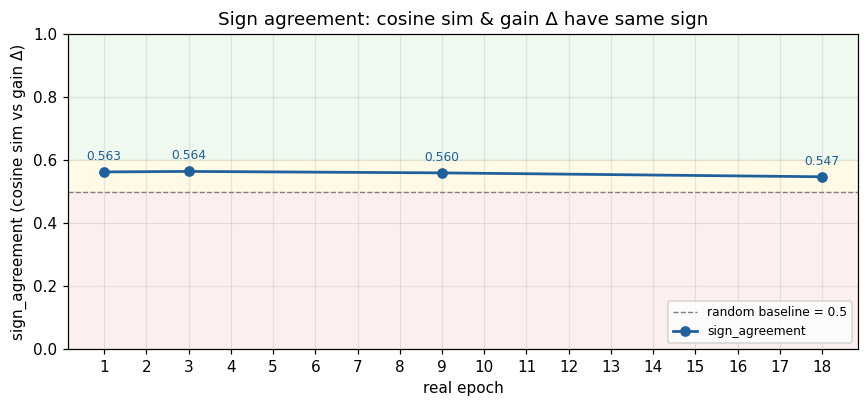


[verdict] mean sign_agreement = 0.558, last epoch = 0.547 → 약함 — random 보다 약간 나음. surgery hook 결정엔 위험


In [23]:
# 5.3b sign_agreement 단독 시각화
# §5.3 의 3 metric 중 sign_agreement 만 따로 본다. random baseline=0.5 (binary 부호) 기준선과
# 약/강 zone 을 함께 그어 한 눈에 판정.
if pi_agreement.empty or 'sign_agreement' not in pi_agreement.columns:
    print('[sign_agreement] empty or column missing')
else:
    agg = pi_agreement.sort_values('epoch').reset_index(drop=True)
    show_cols = [c for c in ['checkpoint', 'iter', 'epoch', 'sign_agreement', 'n_joined']
                 if c in agg.columns]
    display(agg[show_cols].round(4))

    fig, ax = plt.subplots(figsize=(8, 3.8))

    # zone 배경: <0.5 random 이하 / 0.5~0.6 약함 / >0.6 쓸만함
    ax.axhspan(0.0, 0.5, color='#fde0e0', alpha=0.5, label='_random or worse')
    ax.axhspan(0.5, 0.6, color='#fff7d6', alpha=0.6, label='_weak')
    ax.axhspan(0.6, 1.0, color='#e1f4e0', alpha=0.5, label='_usable')

    # baseline 0.5
    ax.axhline(0.5, color='gray', ls='--', lw=0.9, label='random baseline = 0.5')

    # 곡선
    ax.plot(agg['epoch'], agg['sign_agreement'],
            marker='o', color='#1f5f9c', lw=1.8, label='sign_agreement')

    # 값 라벨
    for _, r in agg.iterrows():
        ax.annotate(f'{r["sign_agreement"]:.3f}',
                    (r['epoch'], r['sign_agreement']),
                    textcoords='offset points', xytext=(0, 8),
                    ha='center', fontsize=8, color='#1f5f9c')

    ax.set_xlabel('real epoch')
    ax.set_ylabel('sign_agreement (cosine sim vs gain Δ)')
    ax.set_title('Sign agreement: cosine sim & gain Δ have same sign')
    ax.set_ylim(0.0, 1.0)
    ax.grid(alpha=0.3)
    ax.legend(loc='lower right', fontsize=8)
    set_epoch_xaxis(ax, step=1)
    plt.tight_layout(); plt.show()

    # 한 줄 판정
    last_val = float(agg['sign_agreement'].iloc[-1])
    mean_val = float(agg['sign_agreement'].mean())
    if mean_val >= 0.6:
        verdict = '쓸만함 — cosine 부호로 방향 결정 가능'
    elif mean_val >= 0.5:
        verdict = '약함 — random 보다 약간 나음. surgery hook 결정엔 위험'
    else:
        verdict = '사용 불가 — cosine 부호가 random 이하. causal probe 필요'
    print(f'\n[verdict] mean sign_agreement = {mean_val:.3f}, last epoch = {last_val:.3f} → {verdict}')

,layer,mean_grad_norm,n,checkpoint,iter,epoch,__file
0,dec0_inter_gnn_0,1.559978,1000,1ep,1758,1.0,planning_layer_sensitivity.csv
1,dec1_inter_gnn_0,2.133804,1000,1ep,1758,1.0,planning_layer_sensitivity.csv
2,dec2_inter_gnn_0,1.359264,1000,1ep,1758,1.0,planning_layer_sensitivity.csv
3,dec0_inter_gnn_0,1.563032,1000,3ep,5274,3.0,planning_layer_sensitivity.csv
4,dec1_inter_gnn_0,1.832293,1000,3ep,5274,3.0,planning_layer_sensitivity.csv
5,dec2_inter_gnn_0,1.283843,1000,3ep,5274,3.0,planning_layer_sensitivity.csv
6,dec0_inter_gnn_0,1.000975,1000,9ep,15822,9.0,planning_layer_sensitivity.csv
7,dec1_inter_gnn_0,1.861784,1000,9ep,15822,9.0,planning_layer_sensitivity.csv
8,dec2_inter_gnn_0,0.780376,1000,9ep,15822,9.0,planning_layer_sensitivity.csv
9,dec0_inter_gnn_0,1.103729,1000,18ep,31644,18.0,planning_layer_sensitivity.csv


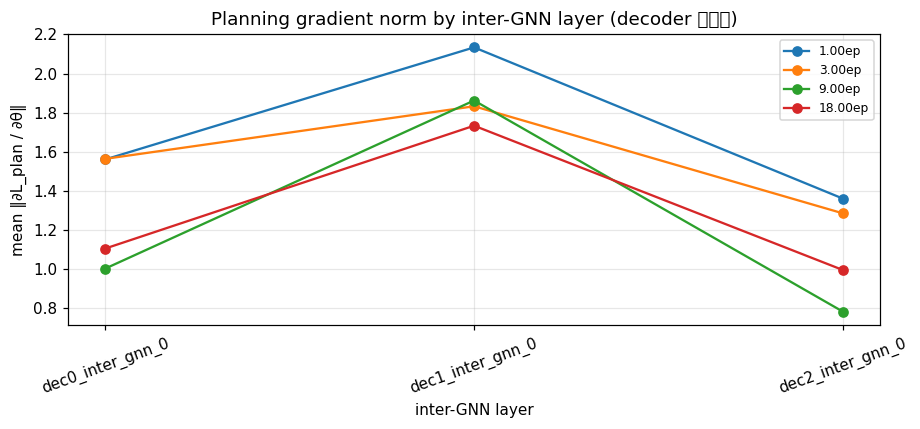

In [24]:
# 5.4 Planning gradient norm by inter-GNN layer (어디서 planning gradient 가 가장 강한가)
if pi_layer_sens.empty:
    print('[planning_layer_sensitivity] empty')
else:
    display(pi_layer_sens.sort_values(['epoch', 'layer']).round(6))
    fig, ax = plt.subplots(figsize=(8.5, 4))
    for ep in sorted(pi_layer_sens['epoch'].unique()):
        sub = pi_layer_sens[pi_layer_sens['epoch'] == ep]
        sub = sub.set_index('layer').reindex(TARGET_LAYERS).reset_index()
        ax.plot(sub['layer'], sub['mean_grad_norm'], marker='o', label=f'{ep:.2f}ep')
    ax.set_xlabel('inter-GNN layer'); ax.set_ylabel('mean ‖∂L_plan / ∂θ‖')
    ax.set_title('Planning gradient norm by inter-GNN layer (decoder 깊이별)')
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.xticks(rotation=20); plt.tight_layout(); plt.show()

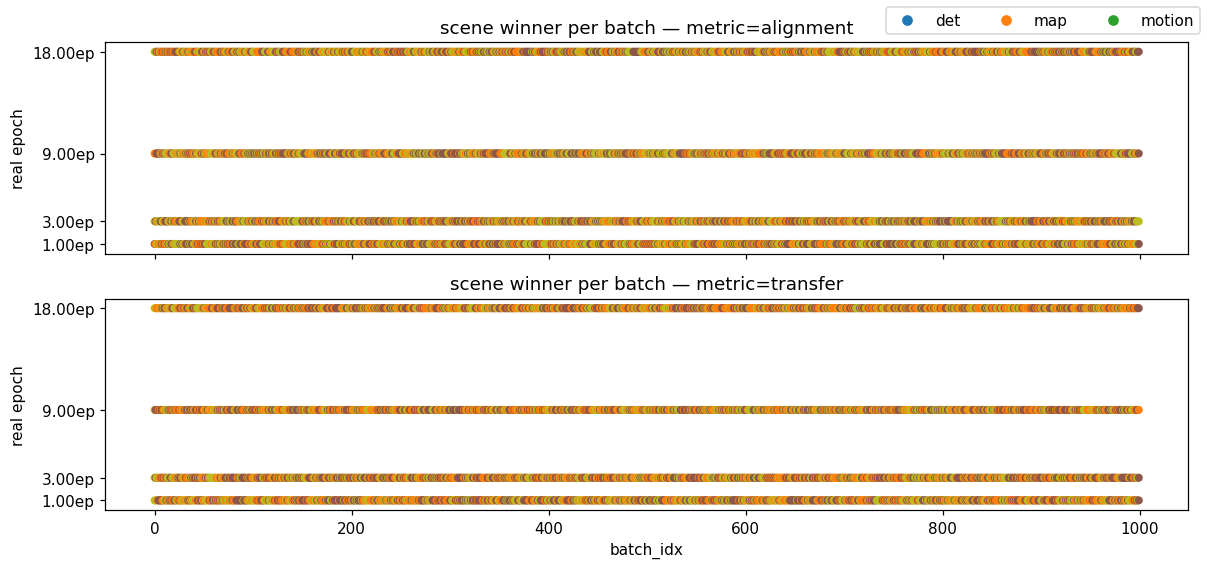

In [25]:
# 5.5 Scene winner per-batch — batch 시간축 위에 어떤 aux task 가 우승했는지 (scene 의존성)
if pi_winner_pb.empty:
    print('[scene_winner_per_batch] empty')
else:
    win_col = 'winner_task' if 'winner_task' in pi_winner_pb.columns else 'winner'
    metrics = sorted(pi_winner_pb['metric'].unique())
    aux_codes = {t: i for i, t in enumerate(['det', 'map', 'motion'])}
    fig, axes = plt.subplots(len(metrics), 1,
                             figsize=(11, 2.6 * len(metrics)),
                             squeeze=False, sharex=True)
    for ax, m in zip(axes[:, 0], metrics):
        sub = pi_winner_pb[pi_winner_pb['metric'] == m].copy()
        for ep in sorted(sub['epoch'].unique()):
            s2 = sub[sub['epoch'] == ep].sort_values('batch_idx')
            ys = s2[win_col].map(aux_codes)
            ax.scatter(s2['batch_idx'], [ep] * len(s2),
                       c=ys, cmap='tab10', s=18, vmin=-0.5, vmax=2.5)
        ax.set_yticks(sorted(sub['epoch'].unique()))
        ax.set_yticklabels([f'{e:.2f}ep' for e in sorted(sub['epoch'].unique())])
        ax.set_ylabel('real epoch'); ax.set_title(f'scene winner per batch — metric={m}')
    axes[-1, 0].set_xlabel('batch_idx')
    handles = [plt.Line2D([], [], marker='o', linestyle='', color=plt.cm.tab10(v / 10),
                          label=t) for t, v in aux_codes.items()]
    fig.legend(handles=handles, loc='upper right', ncol=3)
    plt.tight_layout(); plt.show()

## 6. Checkpoint dynamics 종합

**왜 이 섹션을 따로 두는가** — `v3` 노트북은 `dynamics/cos_dynamics.csv` 등 이미 epoch 축으로 정리된 산출물을 썼지만, 본 scope (`inter_gnn_v1`) 는 그 디렉터리가 없다. 그래서 위에서 모은 stack 데이터로 직접 epoch 축을 합성한다.

### 6.1 Layer-avg conflict & mean_cos 추세
- 모든 6 inter-GNN layer 의 평균. pair 별로 epoch 에 따라 conflict_ratio 가 줄어드는지(학습 후반에 충돌 약화), 특정 pair 만 계속 high 인지 확인.

### 6.2 Off-diag Δloss heatmap (epoch × pair)
- raw 1-step probe 의 비대각 entry (= cross-task transfer) 만 모아 `epoch × (s→t)` heatmap.
- 한 화면에서 어느 pair 가 학습 내내 "파랑(도움)" 또는 "빨강(간섭)" 으로 안정적인지 본다.

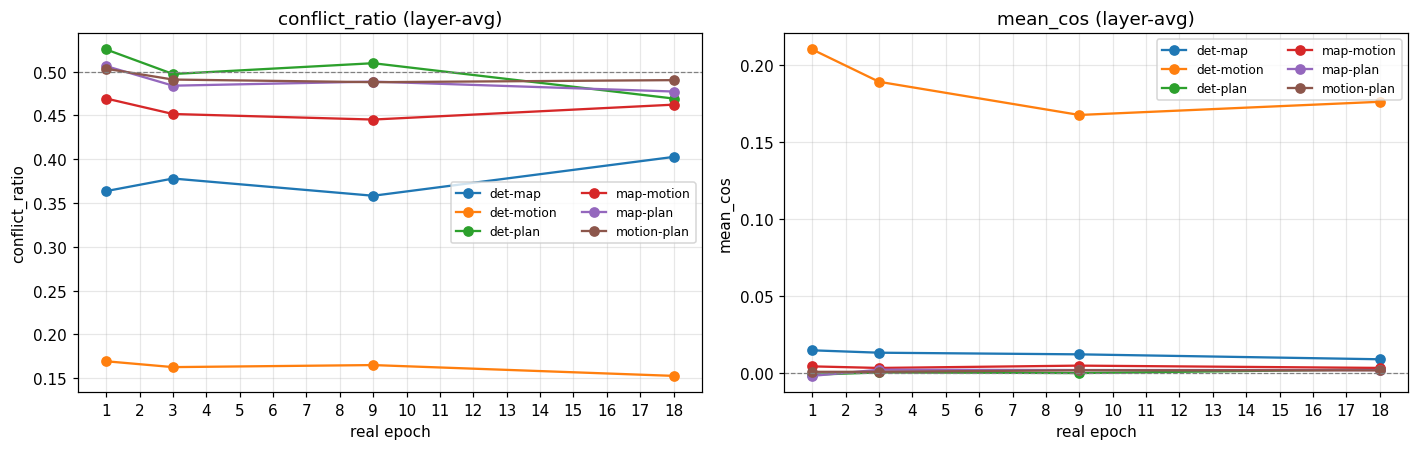

In [26]:
# 6.1 layer-average conflict_ratio + mean_cos over epochs (per task pair)
if not real_layer.empty:
    agg = (real_layer.groupby(['epoch', 'iter', 'task_a', 'task_b'], as_index=False)
                     .agg(conflict_ratio=('conflict_ratio', 'mean'),
                          mean_cos=('mean_cos', 'mean')))
    agg['pair'] = agg['task_a'] + '-' + agg['task_b']
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
    for ax, col, ref, ttl in zip(axes, ['conflict_ratio', 'mean_cos'], [0.5, 0.0],
                                 ['conflict_ratio (layer-avg)', 'mean_cos (layer-avg)']):
        for pair, pdf in agg.groupby('pair'):
            pdf = pdf.sort_values('epoch')
            ax.plot(pdf['epoch'], pdf[col], marker='o', label=pair)
        ax.axhline(ref, color='gray', ls='--', lw=0.8)
        ax.set_xlabel('real epoch'); ax.set_ylabel(col); ax.set_title(ttl)
        ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2)
        set_epoch_xaxis(ax, step=1)
    plt.tight_layout(); plt.show()

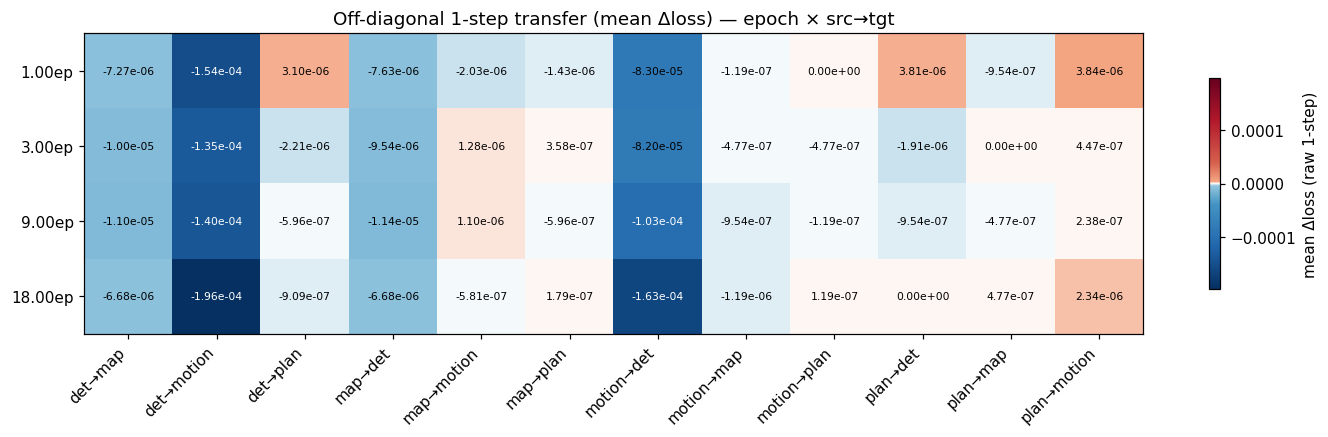

In [27]:
# 6.2 off-diagonal probe Δloss heatmap: epoch × (src→tgt)
if not probe_per_batch.empty:
    pr = probe_per_batch[(probe_per_batch['variant'] == DEFAULT_PROBE_VARIANT)
                         & (probe_per_batch['steps'] == 1)
                         & (probe_per_batch['source_task'] != probe_per_batch['target_task'])].copy()
    pr['pair'] = pr['source_task'] + '→' + pr['target_task']
    mat = (pr.groupby(['epoch', 'pair'])['delta'].median()
             .unstack('pair').sort_index())
    vmax = np.nanmax(np.abs(mat.values)) or 1e-12
    fig, ax = plt.subplots(figsize=(13, 2.8 + 0.32 * len(mat)))
    im = ax.imshow(mat.values, cmap=NARROW_RDBU, vmin=-vmax, vmax=vmax, aspect='auto')
    ax.set_xticks(range(mat.shape[1])); ax.set_xticklabels(mat.columns, rotation=45, ha='right')
    ax.set_yticks(range(mat.shape[0])); ax.set_yticklabels([f'{e:.2f}ep' for e in mat.index])
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.values[i, j]
            if np.isfinite(v):
                ax.text(j, i, f'{v:.2e}', ha='center', va='center', fontsize=7,
                        color='white' if abs(v) > 0.45 * vmax else 'black')
    plt.colorbar(im, ax=ax, shrink=0.7, label='mean Δloss (raw 1-step)')
    ax.set_title('Off-diagonal 1-step transfer (mean Δloss) — epoch × src→tgt')
    plt.tight_layout(); plt.show()

## 7. Summary report (top-level)

`summary_report.md` 는 `run_gradient_analysis.py` 가 모든 checkpoint 결과를 다 본 뒤 상위 N 개 conflict 셀과 raw/normalized probe symmetry 검정 결과를 markdown 으로 정리한 파일.

In [28]:
rep = RESULTS_ROOT / 'summary_report.md'
if rep.exists():
    display(Markdown(rep.read_text()))
else:
    print('summary_report.md not found')

# Gradient Analysis Summary


## Highest conflict_ratio (real shared groups)

| checkpoint   | task_a   | task_b   | group     |   n_total |   n_valid |   conflict_ratio |     mean_cos |   pseudo_shared_ratio |
|:-------------|:---------|:---------|:----------|----------:|----------:|-----------------:|-------------:|----------------------:|
| 1ep          | det      | plan     | neck      |      1000 |      1000 |            0.565 | -0.00963373  |                     0 |
| 1ep          | motion   | plan     | fc_before |      1000 |      1000 |            0.549 | -0.00883621  |                     0 |
| 1ep          | det      | plan     | fc_before |      1000 |      1000 |            0.539 | -0.00762633  |                     0 |
| 1ep          | motion   | plan     | fc_after  |      1000 |      1000 |            0.525 | -0.00368313  |                     0 |
| 1ep          | motion   | plan     | neck      |      1000 |      1000 |            0.514 | -0.000662484 |                     0 |
| 1ep          | det      | plan     | fc_after  |      1000 |      1000 |            0.509 | -0.00262769  |                     0 |
| 1ep          | map      | motion   | fc_after  |      1000 |      1000 |            0.488 |  0.00232859  |                     0 |
| 1ep          | map      | plan     | fc_before |      1000 |      1000 |            0.483 |  0.00584572  |                     0 |
| 1ep          | map      | plan     | fc_after  |      1000 |      1000 |            0.473 |  0.00386633  |                     0 |
| 1ep          | map      | motion   | neck      |      1000 |      1000 |            0.47  |  0.00830685  |                     0 |


## Lowest conflict_ratio (real shared groups)

| checkpoint   | task_a   | task_b   | group     |   n_total |   n_valid |   conflict_ratio |   mean_cos |   pseudo_shared_ratio |
|:-------------|:---------|:---------|:----------|----------:|----------:|-----------------:|-----------:|----------------------:|
| 1ep          | det      | motion   | fc_after  |      1000 |      1000 |            0.151 | 0.158318   |                     0 |
| 1ep          | det      | motion   | fc_before |      1000 |      1000 |            0.171 | 0.205621   |                     0 |
| 1ep          | det      | motion   | neck      |      1000 |      1000 |            0.197 | 0.180151   |                     0 |
| 1ep          | det      | map      | neck      |      1000 |      1000 |            0.28  | 0.0431554  |                     0 |
| 1ep          | det      | map      | fc_before |      1000 |      1000 |            0.359 | 0.0394258  |                     0 |
| 1ep          | det      | map      | fc_after  |      1000 |      1000 |            0.373 | 0.0204     |                     0 |
| 1ep          | map      | plan     | neck      |      1000 |      1000 |            0.455 | 0.00666689 |                     0 |
| 1ep          | map      | motion   | fc_before |      1000 |      1000 |            0.464 | 0.00802178 |                     0 |
| 1ep          | map      | motion   | neck      |      1000 |      1000 |            0.47  | 0.00830685 |                     0 |
| 1ep          | map      | plan     | fc_after  |      1000 |      1000 |            0.473 | 0.00386633 |                     0 |


## Raw vs Normalized probe symmetry (Frobenius of antisymmetric Δloss)


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


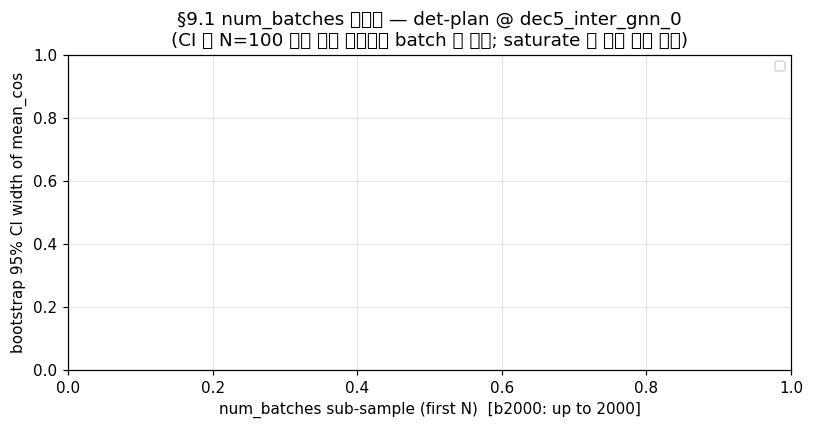

### §9.2 winner run-length — observed vs random shuffle baseline


,ckpt,epoch,metric,observed_mean_run,shuffle_baseline,ratio_obs_vs_shuffle
0,1ep,1.0,alignment,1.546,1.507,1.026
1,1ep,1.0,transfer,1.534,1.504,1.020
2,3ep,3.0,alignment,1.433,1.512,0.948
3,3ep,3.0,transfer,1.477,1.523,0.970
4,9ep,9.0,alignment,1.541,1.515,1.017
5,9ep,9.0,transfer,1.451,1.519,0.955
6,18ep,18.0,alignment,1.511,1.500,1.007
7,18ep,18.0,transfer,1.570,1.523,1.031


해석: ratio > 1.5 = winner 가 batch_idx 시간축에서 cluster (인접 batch_idx 가 비슷한 task 를 winner 로 만듦 → batch 구성과 연관).
       ratio ≈ 1.0 = random — entropy 0.997 은 noise 의 균등 분포일 뿐.

### §9.3 cosine 분포 모양 — std, IQR, Sarle bimodality coefficient
-- cosine std (epoch 별, layer 평균) --


epoch,1.0,3.0,9.0,18.0
pair,,,,
det_map,0.0391,0.0431,0.0383,0.0413
det_motion,0.2241,0.2135,0.1919,0.1910
det_plan,0.0361,0.0326,0.0265,0.0297
map_motion,0.0474,0.0473,0.0452,0.0436
map_plan,0.0496,0.0440,0.0376,0.0381
motion_plan,0.0454,0.0481,0.0355,0.0378


해석: std 가 epoch 따라 감소 → subspace 분리 진행 중.
       평탄 → 처음부터 직교 (capacity 가 처음부터 충분).

-- bimodal 후보 없음 — 모든 셀이 unimodal (또는 noise) --


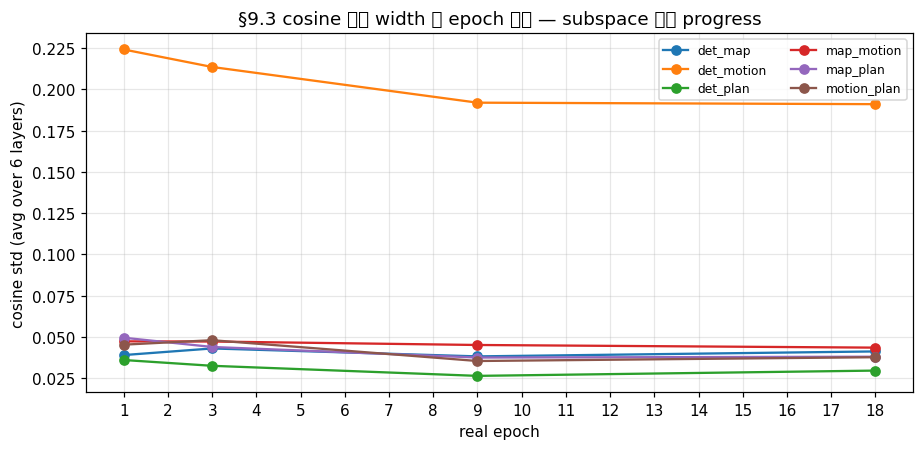

In [29]:
# ========================================================================
# §9. Diagnostics — 측정 setup 자체의 sanity (학습/anal 재실행 X, CSV 만)
# ========================================================================
# 세 질문에 답:
#   §9.1  신호 약함이 N=100 batch 부족 때문인가?
#         → bootstrap CI width 가 N 따라 어떻게 변하나
#   §9.2  winner entropy 0.997 이 "batch 마다 winner 다름" 인가, 그냥 noise 인가?
#         → winner 시퀀스의 run-length vs shuffle baseline 비율
#   §9.3  cosine 분포가 학습 따라 좁아지나(subspace 분리), 안 좁아지나(원래 직교)?
#         → std/IQR + bimodality coefficient 의 epoch 추세
#
# 주의 ("scene" 용어): 정확히는 "batch_idx". anal 코드가 nuScenes scene_token
# 매핑은 저장 안 했음. "scene-dep" 같은 결론은 batch_idx 시간축 cluster 여부로만
# 추정 가능.
#
# 주의 (probe 동작): 모델 파라미터는 분석 도중 절대 update 안 됨.
# probe.py 의 in-place virtual step → forward → restore 패턴. 1ep/3ep/9ep/18ep 는
# 별도 학습된 ckpt 4개를 따로 로드한 것이고, 같은 ckpt 안 batch 100개는 같은
# θ_0 위 독립 측정.

# ---- 9.1 num_batches 충분성 ----
PER_BATCH_REL = 'layer_conflict/conflict_det_plan_per_batch.csv'
N_GRID = [50, 200, 500, 1000, 2000]   # b2000 run: 2000-batch ceiling
N_BOOT = 300
TARGET_LAYER_FOR_N = 'dec5_inter_gnn_0'

fig, ax = plt.subplots(figsize=(7.5, 4))
rng = np.random.default_rng(0)
for tag, it, ep, p in CKPTS:
    f = p / PER_BATCH_REL
    if not f.exists():
        continue
    df = pd.read_csv(f)
    cos_col = next((c for c in ['cos', 'mean_cos'] if c in df.columns), None)
    grp_col = 'group' if 'group' in df.columns else 'layer'
    if cos_col is None:
        continue
    arr = df[df[grp_col] == TARGET_LAYER_FOR_N][cos_col].values
    if arr.size == 0:
        continue
    widths = []
    for N in N_GRID:
        if arr.size < N:
            widths.append(np.nan); continue
        sub = arr[:N]
        boots = np.array([rng.choice(sub, N, replace=True).mean() for _ in range(N_BOOT)])
        widths.append(np.percentile(boots, 97.5) - np.percentile(boots, 2.5))
    ax.plot(N_GRID, widths, marker='o', label=f'{tag} (ep={ep:.0f})')
ax.set_xlabel('num_batches sub-sample (first N)  [b2000: up to 2000]')
ax.set_ylabel('bootstrap 95% CI width of mean_cos')
ax.set_title(f'§9.1 num_batches 충분성 — det-plan @ {TARGET_LAYER_FOR_N}\n'
             '(CI 가 N=100 까지 계속 좁아지면 batch 더 필요; saturate 면 진짜 신호 부재)')
ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


# ---- 9.2 winner run-length: cluster vs random ----
def _runs(seq):
    seq = list(seq)
    if not seq:
        return []
    runs, cur = [], 1
    for i in range(1, len(seq)):
        if seq[i] == seq[i-1]:
            cur += 1
        else:
            runs.append(cur); cur = 1
    runs.append(cur)
    return runs

print('### §9.2 winner run-length — observed vs random shuffle baseline')
if pi_winner_pb.empty:
    print('[scene_winner_per_batch] empty')
else:
    win_col = 'winner_task' if 'winner_task' in pi_winner_pb.columns else 'winner'
    rng2 = np.random.default_rng(0)
    rows = []
    for tag, it, ep, p in CKPTS:
        for m in sorted(pi_winner_pb['metric'].unique()):
            sub = (pi_winner_pb[(pi_winner_pb['checkpoint'] == tag)
                                & (pi_winner_pb['metric'] == m)]
                   .sort_values('batch_idx'))
            if sub.empty:
                continue
            seq = sub[win_col].tolist()
            obs = float(np.mean(_runs(seq)))
            shuf_means = []
            for _ in range(200):
                arr = np.array(seq)
                rng2.shuffle(arr)
                shuf_means.append(np.mean(_runs(arr.tolist())))
            base = float(np.mean(shuf_means))
            rows.append({
                'ckpt': tag, 'epoch': ep, 'metric': m,
                'observed_mean_run':     round(obs, 3),
                'shuffle_baseline':      round(base, 3),
                'ratio_obs_vs_shuffle':  round(obs / base, 3) if base > 0 else np.nan,
            })
    rl_df = pd.DataFrame(rows)
    display(rl_df)
    print('해석: ratio > 1.5 = winner 가 batch_idx 시간축에서 cluster '
          '(인접 batch_idx 가 비슷한 task 를 winner 로 만듦 → batch 구성과 연관).')
    print('       ratio ≈ 1.0 = random — entropy 0.997 은 noise 의 균등 분포일 뿐.')


# ---- 9.3 cosine 분포 width / bimodality 의 epoch 추세 ----
def _skew(x):
    x = np.asarray(x, float); s = x.std()
    return 0.0 if s == 0 else ((x - x.mean()) ** 3).mean() / (s ** 3)

def _kurt(x):  # Fisher excess kurtosis
    x = np.asarray(x, float); s = x.std()
    return 0.0 if s == 0 else ((x - x.mean()) ** 4).mean() / (s ** 4) - 3

print('\n### §9.3 cosine 분포 모양 — std, IQR, Sarle bimodality coefficient')
PAIRS = ['det_map', 'det_motion', 'det_plan', 'map_motion', 'map_plan', 'motion_plan']
shape_rows = []
for tag, it, ep, p in CKPTS:
    for pair in PAIRS:
        f = p / f'layer_conflict/conflict_{pair}_per_batch.csv'
        if not f.exists():
            continue
        df = pd.read_csv(f)
        cos_col = next((c for c in ['cos', 'mean_cos'] if c in df.columns), None)
        grp_col = 'group' if 'group' in df.columns else 'layer'
        if cos_col is None:
            continue
        for L in TARGET_LAYERS:
            arr = df[df[grp_col] == L][cos_col].values
            if arr.size < 5:
                continue
            sk = _skew(arr); ku = _kurt(arr)
            bimod = (sk ** 2 + 1) / max(ku + 3, 1e-6)   # Sarle's; >5/9 → bimodal 후보
            shape_rows.append({
                'pair': pair, 'layer': L, 'ckpt': tag, 'epoch': ep,
                'mean': round(float(arr.mean()), 4),
                'std':  round(float(arr.std()),  4),
                'iqr':  round(float(np.percentile(arr, 75) - np.percentile(arr, 25)), 4),
                'bimod_coef': round(bimod, 3),
            })
shape_df = pd.DataFrame(shape_rows)

if shape_df.empty:
    print('[shape_df] empty')
else:
    pivot_std = (shape_df.groupby(['pair', 'epoch'])['std']
                 .mean().unstack('epoch').round(4))
    print('-- cosine std (epoch 별, layer 평균) --')
    display(pivot_std)
    print('해석: std 가 epoch 따라 감소 → subspace 분리 진행 중.')
    print('       평탄 → 처음부터 직교 (capacity 가 처음부터 충분).')

    bimod_cells = (shape_df[shape_df['bimod_coef'] > 5/9]
                   .sort_values('bimod_coef', ascending=False))
    if not bimod_cells.empty:
        print(f'\n-- bimodal 후보 cells (Sarle > 5/9), 총 {len(bimod_cells)}개 (상위 20개) --')
        display(bimod_cells.head(20))
        print('해석: cosine 이 +/− 두 mode. 평균 ≈ 0 이 평균효과로 가린 진짜 신호일 수 있음.')
    else:
        print('\n-- bimodal 후보 없음 — 모든 셀이 unimodal (또는 noise) --')

    fig, ax = plt.subplots(figsize=(8.5, 4.2))
    for pair in pivot_std.index:
        ax.plot(pivot_std.columns, pivot_std.loc[pair], marker='o', label=pair)
    ax.set_xlabel('real epoch'); ax.set_ylabel('cosine std (avg over 6 layers)')
    ax.set_title('§9.3 cosine 분포 width 의 epoch 추세 — subspace 분리 progress')
    ax.grid(alpha=0.3); ax.legend(fontsize=8, ncol=2)
    set_epoch_xaxis(ax, step=1)
    plt.tight_layout(); plt.show()


## 8. 정리 — 무엇을 보고 다음에 무엇을 할 것인가

- **§4.5/4.6** 결과가 이 노트북의 핵심 차이점. PCGrad probe 가 보여주는 *방향-only* vs *shrinkage*
  분해는 "PCGrad 가 단순히 step magnitude 를 줄여서 도움이 되는가, 아니면 진짜로 방향을 바꿔
  도움이 되는가" 를 분리한다.
- **§4.5** 의 `other_task` 슬라이스: 어느 task gradient 가 source 의 방향을 가장 크게 바꾸는지,
  그리고 그 결과 target task loss 가 어떻게 바뀌는지 보여준다. plan column 이 의미 있게 음수
  (=transfer) 인 cell 이 PCGrad 가 "plan 에 도움이 되는" 후보.
- **1ep 포함 여부** (§1.1) 토글로 켜고 끄면서 §6.1/6.2 epoch curve 가 1ep 의 존재 여부에 얼마나
  민감한지 확인. 1ep 만 outlier 처럼 튀면 batch-skip 잔재일 가능성이 있다 — `skipped_batches.csv`
  (§1.2) 의 갯수와 함께 해석.
- 다음 단계: `inter_gnn_b1000_pcgrad` 의 §4.5 결과를 `inter_gnn_b2000` (raw/normalized) 와 비교
  하여 "normalized 가 보여준 dec4/dec5 FLIP 이 PCGrad 변형에서도 나타나는가" 를 확인.
